# Machine Learning Project - 2 

**Note**: This project is done in the Jupyter Notebook.

## **Contents**
- <a href= #link0>Exploratory Data Analysis</a>
- <a href= #link1>Data Preprocessing</a>
- <a href= #link2>Model Building - Original Data</a>
- <a href= #link3>Model Building - Oversampled Data</a>
- <a href= #link4>Model Building - Undersampled Data</a>
- <a href= #link5>Model Performance Improvement using Hyperparameter Tuning</a>
- <a href= #link6>Model Performance Comparison and Final Model Selection</a>
- <a href= #link7>Actionable Insights & Recommendations</a>

In [4]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import BaggingClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.ensemble import AdaBoostClassifier

from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

from imblearn.under_sampling import RandomUnderSampler

from sklearn.model_selection import GridSearchCV

from sklearn.model_selection import RandomizedSearchCV

from sklearn import tree

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    recall_score,
    f1_score,
    precision_score,
    auc,
    roc_curve,
    roc_auc_score
)

# Data Overview

**Data Loading**

In [6]:
easy_visa = pd.read_csv('EasyVisa.csv')

**Creating a copy of the data**

In [7]:
data = easy_visa.copy()
data.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [8]:
print("The number of rows in data:", data.shape[0], "\nThe number of columns in data:", data.shape[1])

The number of rows in data: 25480 
The number of columns in data: 12


**Dataframe Information**

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


**Duplicate Rows**

In [10]:
data.duplicated().sum()

0

There are no duplicated rows in the dataset.

**Checking Missing Values**

In [11]:
data.isnull().sum()

case_id                  0
continent                0
education_of_employee    0
has_job_experience       0
requires_job_training    0
no_of_employees          0
yr_of_estab              0
region_of_employment     0
prevailing_wage          0
unit_of_wage             0
full_time_position       0
case_status              0
dtype: int64

**Case_id**

In [12]:
data['case_id'].nunique

<bound method IndexOpsMixin.nunique of 0           EZYV01
1           EZYV02
2           EZYV03
3           EZYV04
4           EZYV05
           ...    
25475    EZYV25476
25476    EZYV25477
25477    EZYV25478
25478    EZYV25479
25479    EZYV25480
Name: case_id, Length: 25480, dtype: object>

- It is the unique identifier of each person, so we can drop this column.

In [14]:
data = data.drop('case_id', axis= 1)
data.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


**Categorical Column of unique values**

In [15]:
features = data.select_dtypes(include=['object', 'category']).columns.to_list()

for i, feature in enumerate(features):
    print(data[feature].value_counts())
    print('---------------------------------------------')

continent
Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: count, dtype: int64
---------------------------------------------
education_of_employee
Bachelor's     10234
Master's        9634
High School     3420
Doctorate       2192
Name: count, dtype: int64
---------------------------------------------
has_job_experience
Y    14802
N    10678
Name: count, dtype: int64
---------------------------------------------
requires_job_training
N    22525
Y     2955
Name: count, dtype: int64
---------------------------------------------
region_of_employment
Northeast    7195
South        7017
West         6586
Midwest      4307
Island        375
Name: count, dtype: int64
---------------------------------------------
unit_of_wage
Year     22962
Hour      2157
Week       272
Month       89
Name: count, dtype: int64
---------------------------------------------
full_time_position
Y    22773
N     2707
Name


**Numerical Column of unique values**

In [16]:
features = data.select_dtypes(include=['number']).columns.to_list()

for i, feature in enumerate(features):
    print(data[feature].value_counts())
    print('---------------------------------------------')

no_of_employees
183      18
854      16
724      16
766      15
1476     15
         ..
5876      1
5536      1
47866     1
4700      1
40224     1
Name: count, Length: 7105, dtype: int64
---------------------------------------------
yr_of_estab
1998    1134
2005    1051
2001    1017
2007     994
1999     870
        ... 
1842       6
1846       4
1822       4
1810       3
1824       2
Name: count, Length: 199, dtype: int64
---------------------------------------------
prevailing_wage
82560.2800     2
122.6500       2
60948.1500     2
64357.5800     2
108.1200       2
              ..
25713.9800     1
101656.6400    1
65665.5500     1
50.8813        1
70876.9100     1
Name: count, Length: 25454, dtype: int64
---------------------------------------------


**Target Column**

In [17]:
data.groupby(['case_status']).count()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position
case_status,,,,,,,,,,
Certified,17018,17018,17018,17018,17018,17018,17018,17018,17018,17018
Denied,8462,8462,8462,8462,8462,8462,8462,8462,8462,8462


In [18]:
data['case_status'].value_counts(1)*100

case_status
Certified    66.789639
Denied       33.210361
Name: proportion, dtype: float64

**Statistical Summary**

In [19]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_employees,25480.0,5667.043210,22877.928848,-26.0000,1022.00,2109.00,3504.0000,602069.00
yr_of_estab,25480.0,1979.409929,42.366929,1800.0000,1976.00,1997.00,2005.0000,2016.00
prevailing_wage,25480.0,74455.814592,52815.942327,2.1367,34015.48,70308.21,107735.5125,319210.27


In [20]:
data.describe(include= 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
continent,25480,6,Asia,16861,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education_of_employee,25480,4,Bachelor's,10234,NaN,NaN,NaN,NaN,NaN,NaN,NaN
has_job_experience,25480,2,Y,14802,NaN,NaN,NaN,NaN,NaN,NaN,NaN
requires_job_training,25480,2,N,22525,NaN,NaN,NaN,NaN,NaN,NaN,NaN
no_of_employees,25480.0,NaN,NaN,NaN,5667.04321,22877.928848,-26.0,1022.0,2109.0,3504.0,602069.0
yr_of_estab,25480.0,NaN,NaN,NaN,1979.409929,42.366929,1800.0,1976.0,1997.0,2005.0,2016.0
region_of_employment,25480,5,Northeast,7195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
prevailing_wage,25480.0,NaN,NaN,NaN,74455.814592,52815.942327,2.1367,34015.48,70308.21,107735.5125,319210.27
unit_of_wage,25480,4,Year,22962,NaN,NaN,NaN,NaN,NaN,NaN,NaN
full_time_position,25480,2,Y,22773,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# <a name=link0>Exploratory Data Analysis</a>

## Univariate Analysis

### Function for Hist and Box plot

In [24]:
def hist_box(df, col,figsize=(8, 10)):
    fig, axes = plt.subplots(2, 1, figsize=figsize) 
    # Histplot
    sns.histplot(data= df, x= col, ax= axes[0])
    plt.title(col)
    plt.xlabel(col)

    # Boxplot
    sns.boxplot(data= df, x= col, ax= axes[1])
    plt.title(col)
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

### Number of Employees

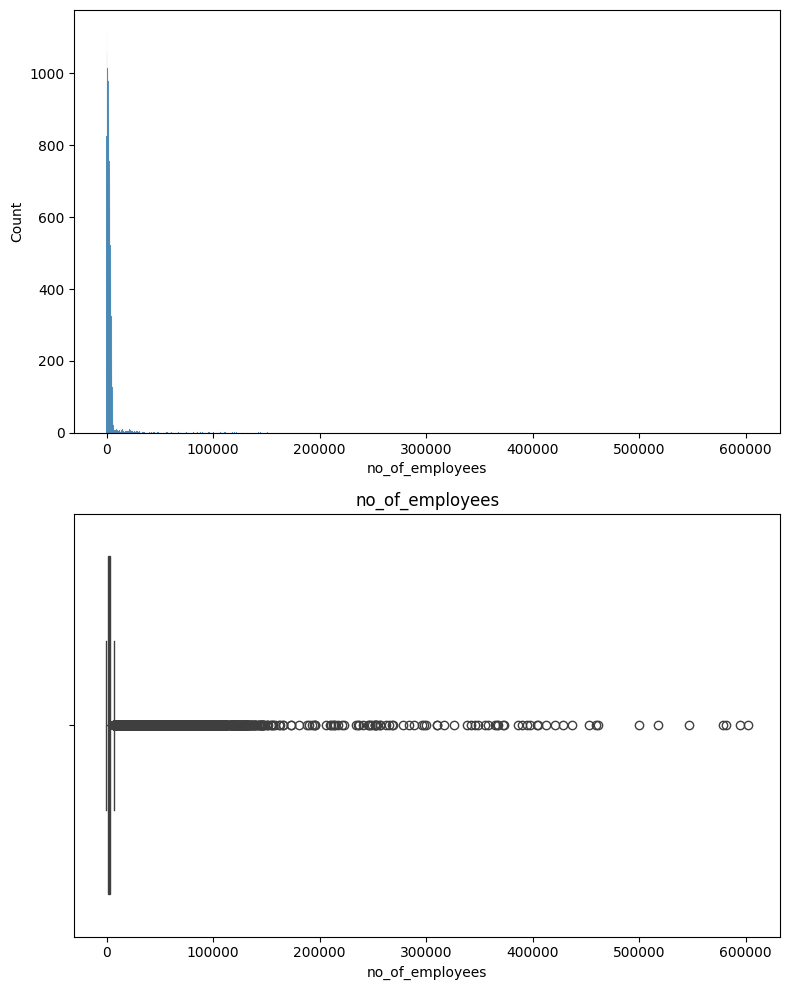

In [25]:
hist_box(data, 'no_of_employees')

**Histogram**: Right-skewed distribution with a long tail, most companies have fewer employees.

**Boxplot**: Shows significant outliers, some companies have extremely high employee counts.

### Year of Establish

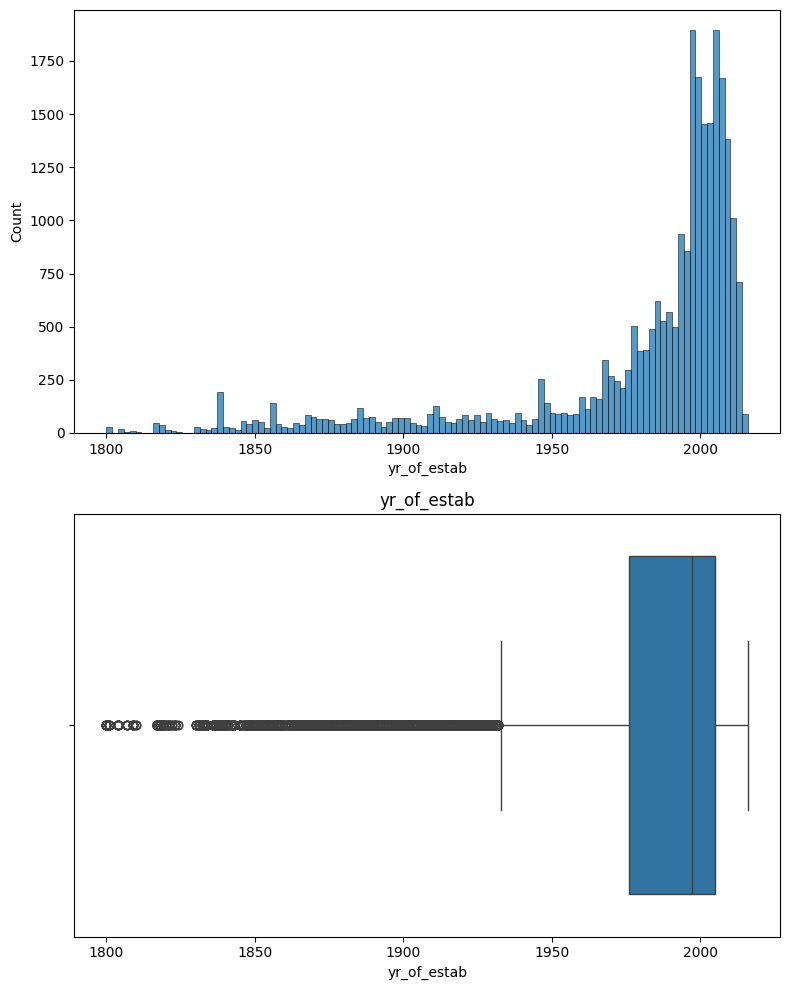

In [26]:
hist_box(data, 'yr_of_estab')

**Histogram**: Left-skewed distribution that peaks around 2000s and early 1900s.

**Boxplot**: Some very early establishments (1800s) are outliers.

### prevailing wage

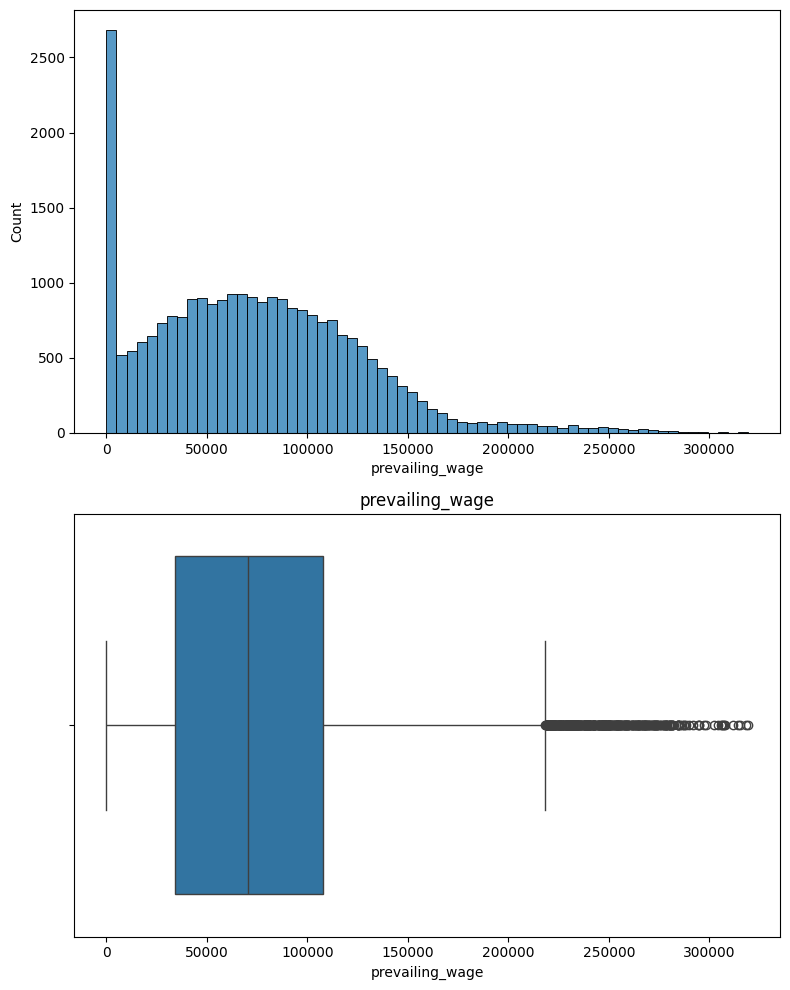

In [27]:
hist_box(data, 'prevailing_wage')

**Histogram**: Highly right-skewed, most wages are concentrated at the lower end.

**Boxplot**: Shows significant outliers, some jobs offer exceptionally high wages.

### Continent

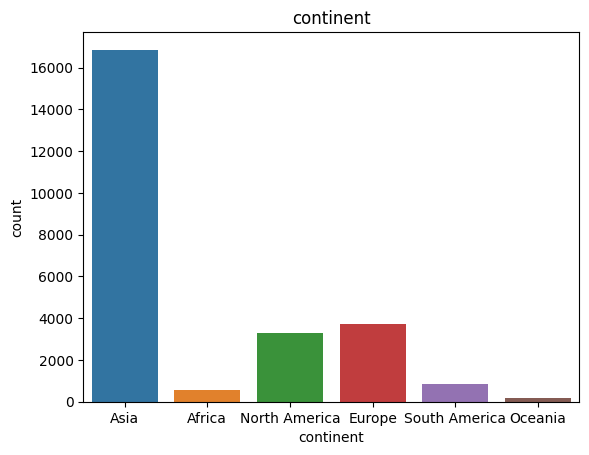

In [28]:
sns.countplot(data= data, x='continent', hue='continent')
plt.title('continent');

- Most applications are from Asia, followed by North America and Europe.

### Education of the employees

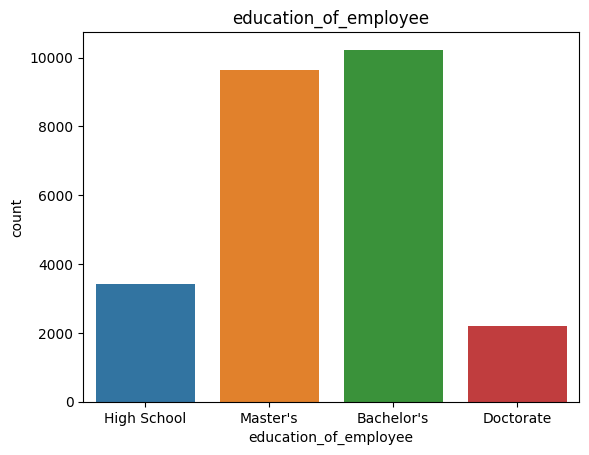

In [29]:
sns.countplot(data= data, x='education_of_employee', hue='education_of_employee')
plt.title('education_of_employee');

- Majority have Bachelor’s or Master’s degrees.

### Job Experience

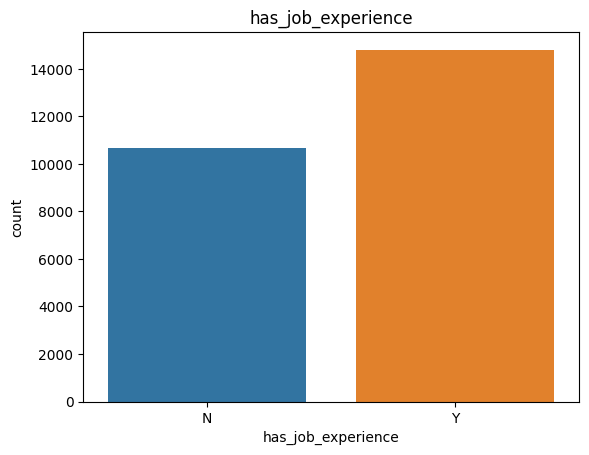

In [30]:
sns.countplot(data= data, x='has_job_experience', hue='has_job_experience')
plt.title('has_job_experience');

- More applicants have job experience than not.

### Job Training

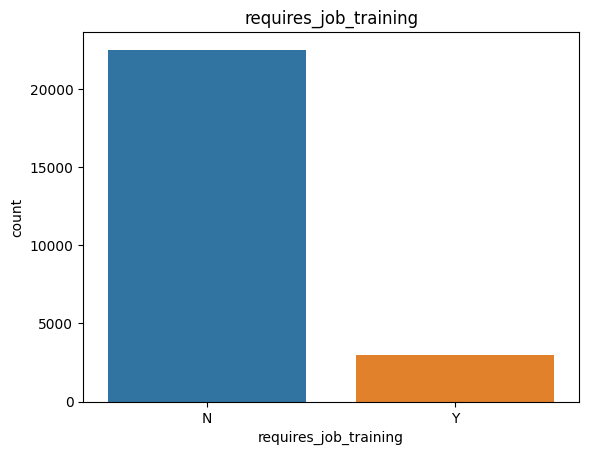

In [31]:
sns.countplot(data= data, x='requires_job_training', hue='requires_job_training')
plt.title('requires_job_training');

- Most applications do not require job training.

### Region of Employment

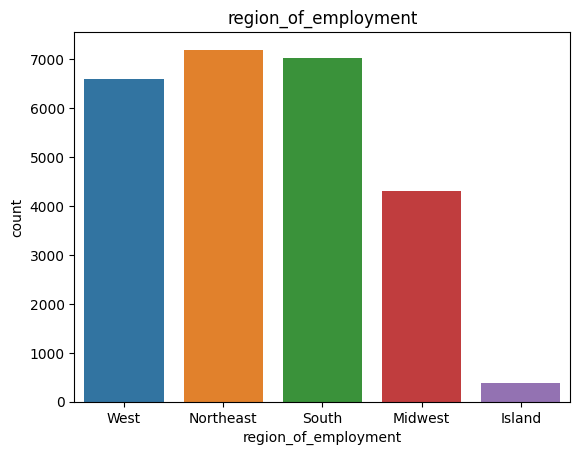

In [32]:
sns.countplot(data= data, x='region_of_employment', hue='region_of_employment')
plt.title('region_of_employment');

- South and West are the most common regions.

### Full time Position

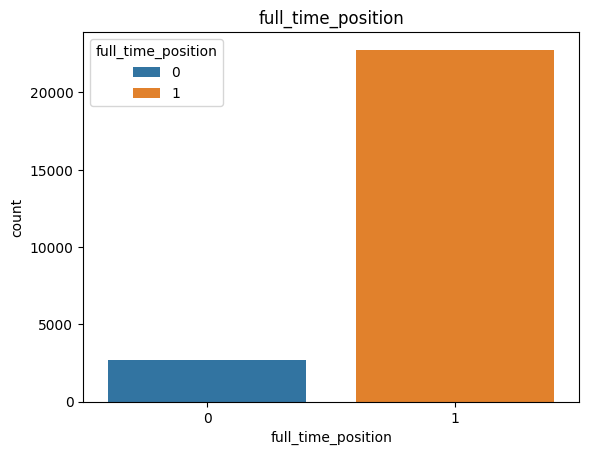

In [857]:
sns.countplot(data= data, x='full_time_position', hue='full_time_position')
plt.title('full_time_position');

- Most positions are full-time.

### Case Status

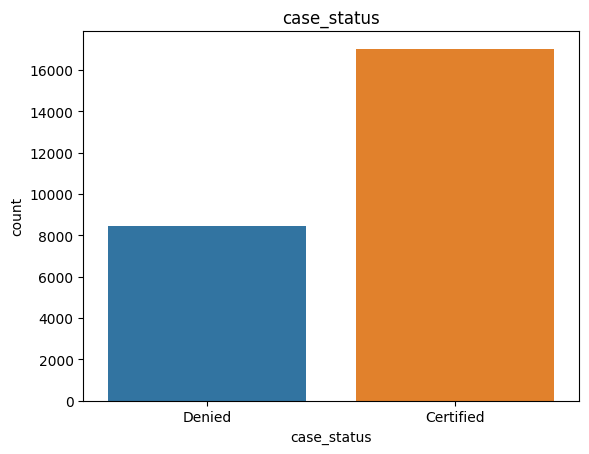

In [34]:
sns.countplot(data= data, x='case_status', hue='case_status')
plt.title('case_status');

- Majority of cases are Certified, but a significant number are Denied.

## Bivariate Analysis

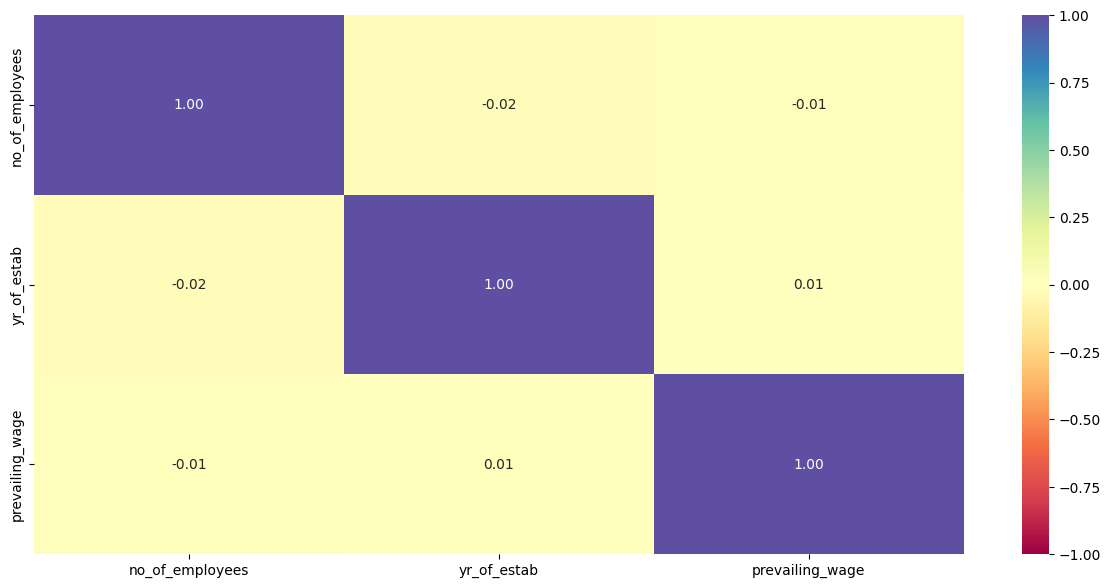

In [36]:
plt.figure(figsize=(15, 7))
features = data.select_dtypes(include=np.number).columns.to_list()
sns.heatmap(data[features].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f",cmap="Spectral")
plt.show()

### Categorical Features vs. Case Status

#### continent vs case_status

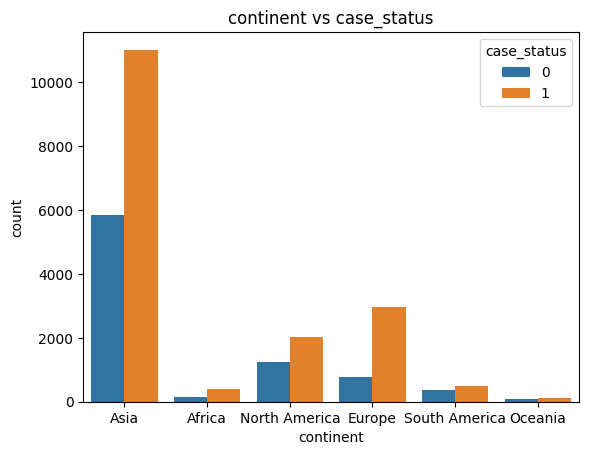

In [870]:
sns.countplot(data=data, x='continent', hue='case_status')
plt.title('continent vs case_status')
plt.show()

- Asia dominates both Certified and Denied cases.
- North America has a higher proportion of Certified cases.

#### education_of_employee vs case_status

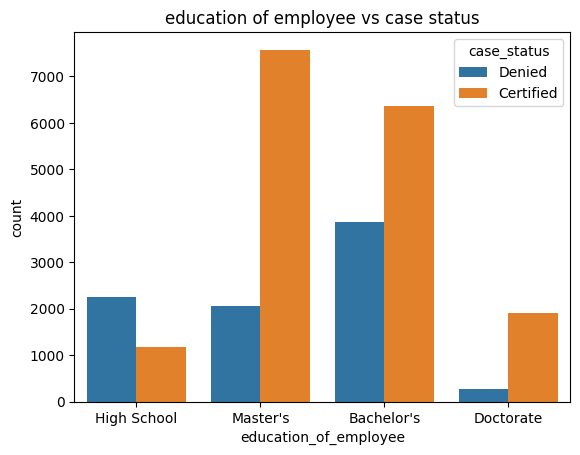

In [38]:
sns.countplot(data=data, x='education_of_employee', hue='case_status')
plt.title('education of employee vs case status')
plt.show()

- Higher education (Master’s, Doctorate) correlates with more certifications.
- High School applicants face more denials.

#### region_of_employment vs case_status

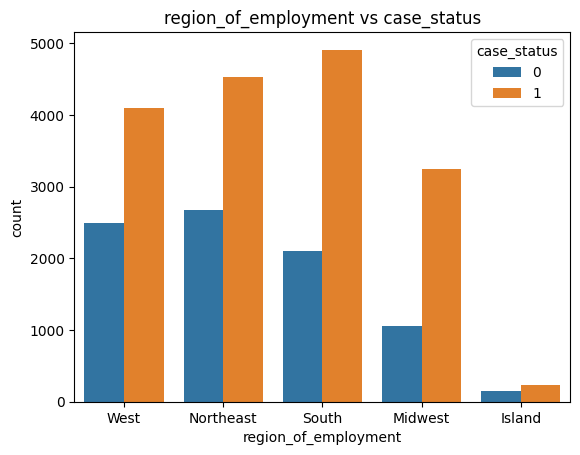

In [876]:
sns.countplot(data=data, x='region_of_employment', hue='case_status')
plt.title('region_of_employment vs case_status')
plt.show()

- South and West regions have more Certified cases.
- Island and Midwest show more balance or denials.

#### full_time_position vs case_status

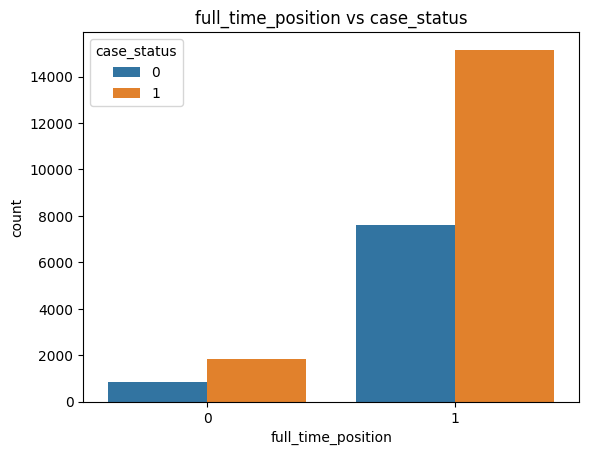

In [880]:
sns.countplot(data=data, x='full_time_position', hue='case_status')
plt.title('full_time_position vs case_status')
plt.show()

- Full-time positions are more likely to be Certified.

### Case_status vs Numerical Columns

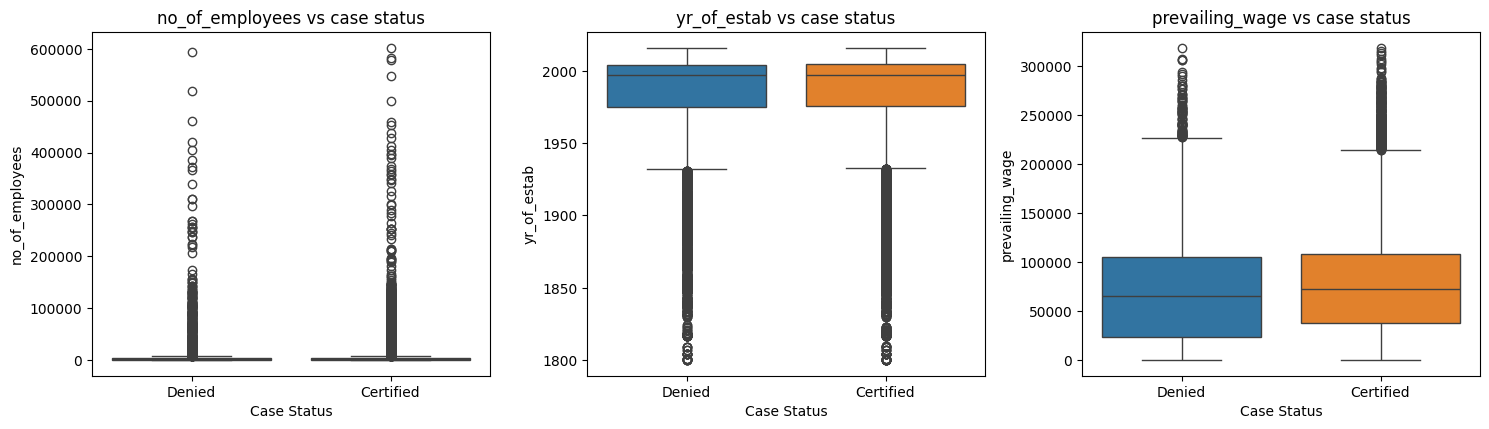

In [42]:
plt.figure(figsize=(15, 12))
categorical_columns = ['no_of_employees','yr_of_estab','prevailing_wage']
for i, column in enumerate(categorical_columns):
    plt.subplot(3,3, i+1)
    sns.boxplot(data=data, x= 'case_status', y=column ,hue='case_status')
    plt.title(f'{column} vs case status')
    plt.xlabel('Case Status')
    plt.ylabel(column)
    
plt.tight_layout()
plt.show()

# <a name=link1>Data Pre-Processing</a>

## Checking Missing Values

In [45]:
data.isnull().sum()

continent                0
education_of_employee    0
has_job_experience       0
requires_job_training    0
no_of_employees          0
yr_of_estab              0
region_of_employment     0
prevailing_wage          0
unit_of_wage             0
full_time_position       0
case_status              0
dtype: int64

There are no Missing values in the dataset.

## Outlier Detection

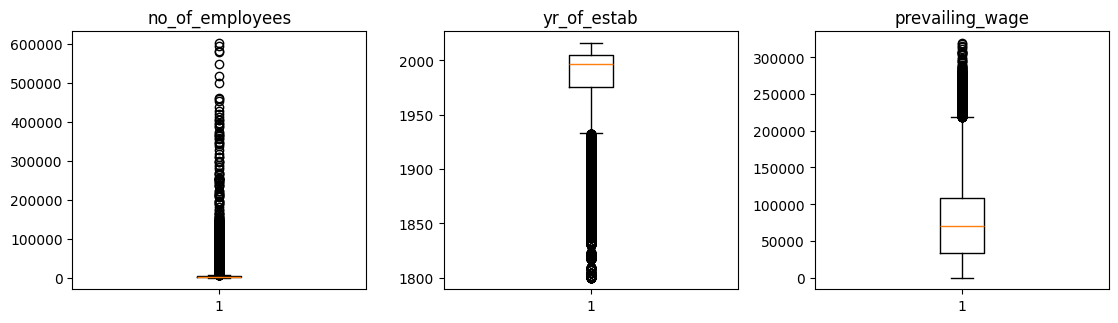

In [48]:
plt.figure(figsize=[15,12])
features = data.select_dtypes(include=['number']).columns.to_list()

for i, feature in enumerate(features):
    plt.subplot(4, 4, i+1)
    plt.boxplot(data[feature] ,whis= 1.5)
    plt.title(feature)
    plt.tight_layout()
    
plt.show()

- Year of establishment and prevailing wage are important, but there are more outliers in the number of employees, so we only treat the number of employees. 

### Treating outliers for the column no_of_employees

In [50]:
def treat_outliers(data, col):
     Q1 = data[col].quantile(0.25)
     Q3 = data[col].quantile(0.75)
     IQR = Q3 - Q1
    
     low_whisker = Q1 - 1.5 * IQR
     high_whisker = Q3 + 1.5 * IQR

     data[col] = data[col].clip(lower= low_whisker, upper= high_whisker)
     return data

In [51]:
treat_outliers(data, 'no_of_employees')

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,Asia,High School,N,N,7227,2007,West,592.2029,Hour,Y,Denied
1,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,Asia,Bachelor's,N,Y,7227,2008,West,122996.8600,Year,Y,Denied
3,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified
...,...,...,...,...,...,...,...,...,...,...,...
25475,Asia,Bachelor's,Y,Y,2601,2008,South,77092.5700,Year,Y,Certified
25476,Asia,High School,Y,N,3274,2006,Northeast,279174.7900,Year,Y,Certified
25477,Asia,Master's,Y,N,1121,1910,South,146298.8500,Year,N,Certified
25478,Asia,Master's,Y,Y,1918,1887,West,86154.7700,Year,Y,Certified


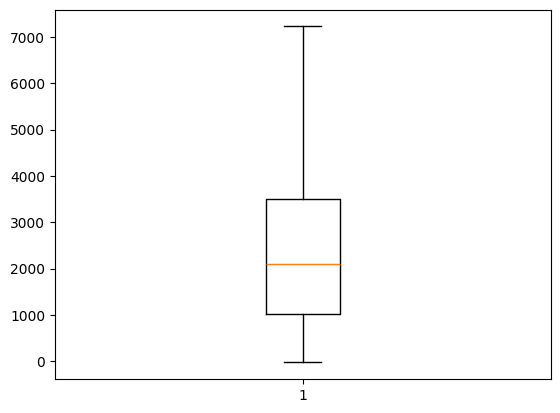

In [52]:
plt.boxplot(data= data, x='no_of_employees');

- The ouliers have been treated

## Feature Engineering

**Label encoding the variables**

In [54]:
data['has_job_experience'] = data['has_job_experience'].apply(lambda x: 1 if x=='Y' else 0)
data['requires_job_training'] = data['requires_job_training'].apply(lambda x: 1 if x=='Y' else 0)
data['full_time_position'] = data['full_time_position'].apply(lambda x: 1 if x=='Y' else 0)

# Target Column
data['case_status'] = data['case_status'].apply(lambda x: 1 if x=='Certified' else 0)

## Data preparation for Modeling

In [56]:
X = data.drop('case_status', axis= 1)
y = data['case_status']

X = pd.get_dummies(
    X,
    columns= X.select_dtypes(include=['object', 'category']).columns.to_list(),
    drop_first= True
)

X = X.astype(float)

### Train, Test and Validation Split

In [57]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.30, random_state=42, stratify=y_temp
)

In [58]:
print("Number of rows & columns in train data =", X_train.shape)
print("Number of rows & columns in validation data =", X_val.shape)
print("Number of rows & columns in test data =", X_test.shape)

Number of rows & columns in train data = (12485, 21)
Number of rows & columns in validation data = (5351, 21)
Number of rows & columns in test data = (7644, 21)


### Scaling the Data

In [59]:
sc = StandardScaler()

X_train_scaled = pd.DataFrame(sc.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_val_scaled = pd.DataFrame(sc.transform(X_val), columns=X_val.columns, index=X_val.index)
X_test_scaled = pd.DataFrame(sc.transform(X_test), columns=X_test.columns, index=X_test.index)

# <a name=link2>Model Building - Original Data</a>

**Function of Model Performance**

In [61]:
def model_performance_stats(model, predictors, target):
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)
    recall = recall_score(target, pred)
    precision = precision_score(target, pred)
    f1 = f1_score(target, pred)

    df_perf = pd.DataFrame({
        "Accuracy": acc, 
        "Recall": recall, 
        "Precision": precision, 
        "F1": f1
    }, index=[0])

    return df_perf

**Function of Confusion Matrix**

In [62]:
def confusion_matrix_stats(model,predictors, target):
    pred = model.predict(predictors)
    
    cm = confusion_matrix(target, pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt="g", cmap= 'Spectral')
    plt.xlabel("Predicted Values")
    plt.ylabel("Actual Values")
    plt.show()

## Decision Tree

In [64]:
Dmodel = DecisionTreeClassifier(random_state= 42)

Dmodel.fit(X_train_scaled, y_train)

DecisionTreeClassifier(random_state=42)

**Train**

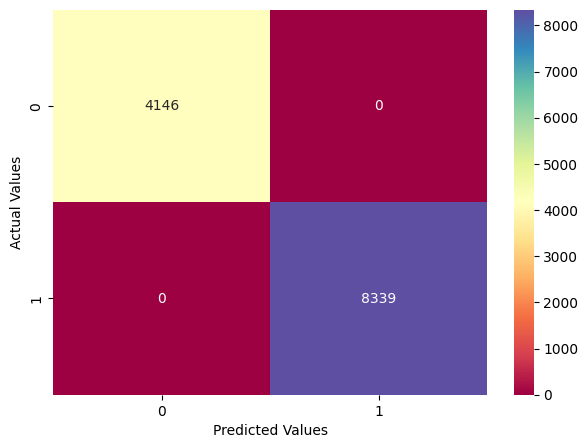

In [66]:
confusion_matrix_stats(Dmodel, X_train_scaled, y_train)

**Test**

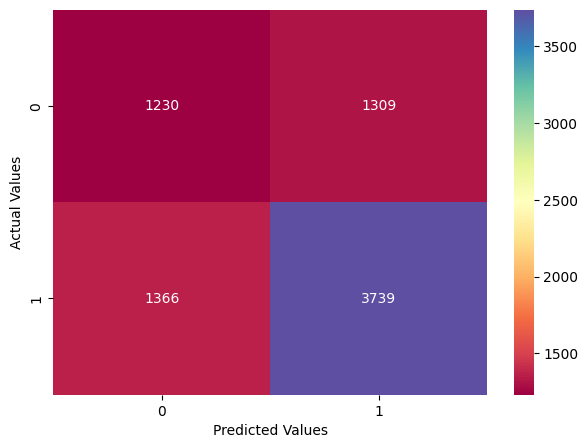

In [68]:
confusion_matrix_stats(Dmodel, X_test_scaled, y_test)

**Train**

In [70]:
decision_tree_default_perf_train = model_performance_stats(Dmodel, X_train_scaled, y_train)
decision_tree_default_perf_train

,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


**Test**

In [72]:
decision_tree_default_perf_test = model_performance_stats(Dmodel, X_test_scaled, y_test)
decision_tree_default_perf_test

,Accuracy,Recall,Precision,F1
0,0.650052,0.732419,0.740689,0.736531


**Train**

AUC: 1.00


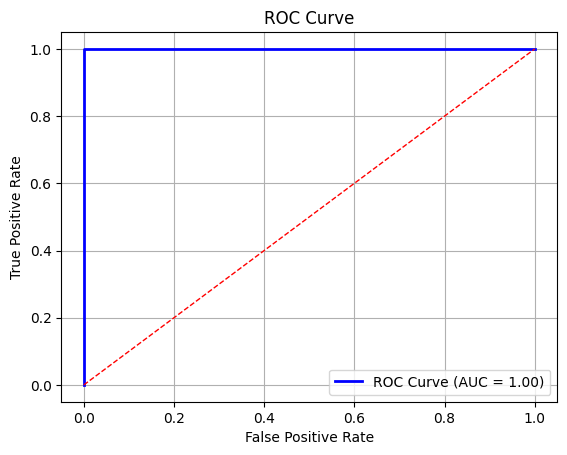

In [74]:
y_pred = Dmodel.predict_proba(X_train_scaled)[:,1]

fpr, tpr, threshold = roc_curve(y_train, y_pred)
roc_auc = auc(fpr, tpr)
print(f"AUC: {roc_auc:.2f}")


plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=1, linestyle='--') 
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

**Test**

AUC: 0.61


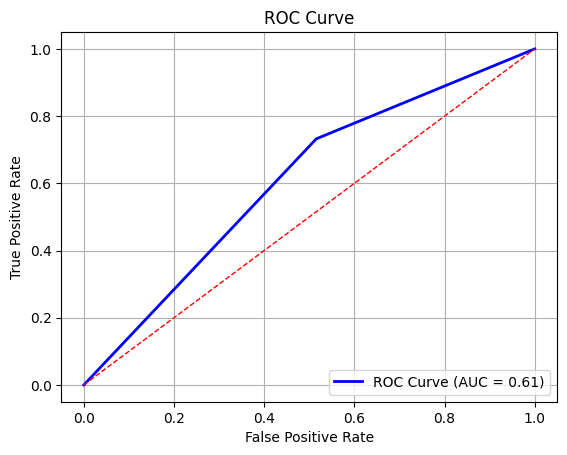

In [1039]:
y_pred = Dmodel.predict_proba(X_test_scaled)[:,1]

fpr, tpr, threshold = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)
print(f"AUC: {roc_auc:.2f}")


plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=1, linestyle='--') 
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

## Bagging

In [78]:
bagg_basic = BaggingClassifier(
    estimator= DecisionTreeClassifier(),
    random_state= 42
)

bagg_basic.fit(X_train_scaled, y_train)

BaggingClassifier(estimator=DecisionTreeClassifier(), random_state=42)

**Train**

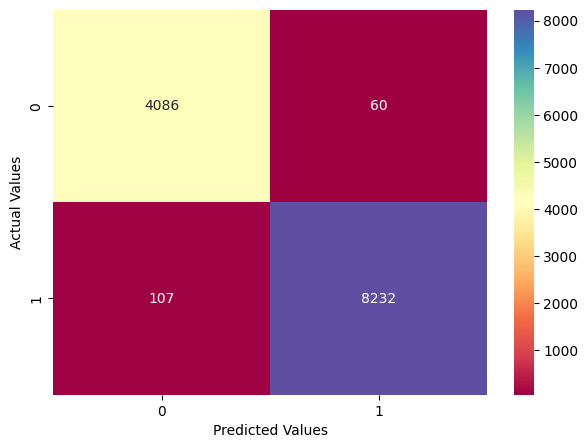

In [80]:
confusion_matrix_stats(bagg_basic, X_train_scaled, y_train)

**Test**

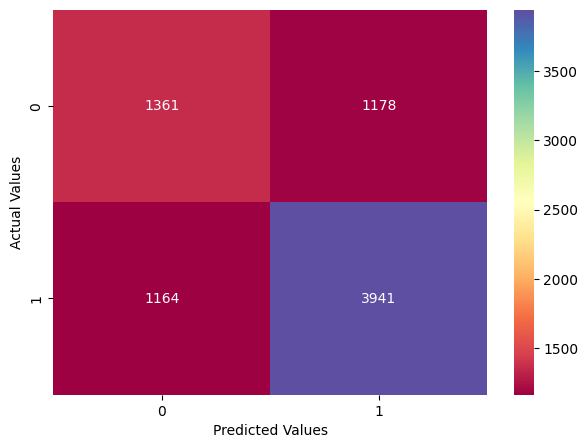

In [82]:
confusion_matrix_stats(bagg_basic, X_test_scaled, y_test)

**Train**

In [84]:
basic_bagging_classifier_train_perf = model_performance_stats(bagg_basic, X_train_scaled, y_train)
basic_bagging_classifier_train_perf

,Accuracy,Recall,Precision,F1
0,0.986624,0.987169,0.992764,0.989959


**Test**

In [86]:
basic_bagging_classifier_test_perf = model_performance_stats(bagg_basic, X_test_scaled, y_test)
basic_bagging_classifier_test_perf

,Accuracy,Recall,Precision,F1
0,0.693616,0.771988,0.769877,0.770931


**Train**

AUC: 1.00


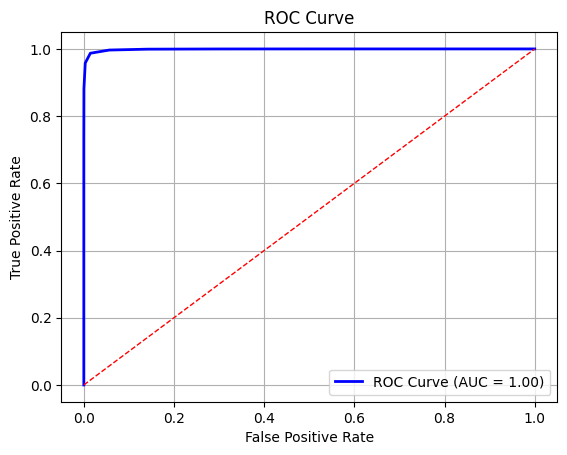

In [88]:
y_pred = bagg_basic.predict_proba(X_train_scaled)[:,1]

fpr, tpr, threshold = roc_curve(y_train, y_pred)
roc_auc = auc(fpr, tpr)
print(f"AUC: {roc_auc:.2f}")


plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=1, linestyle='--') 
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

**Test**

AUC: 0.72


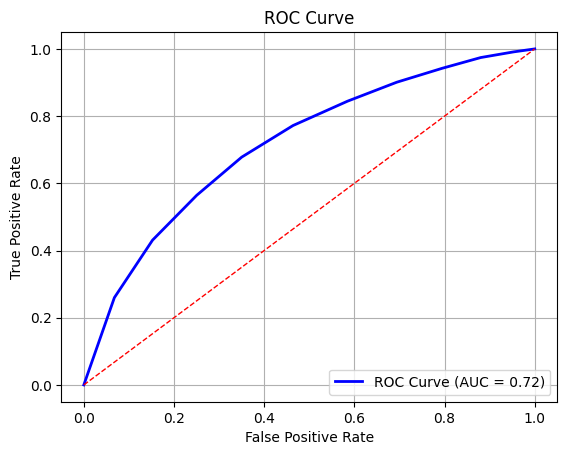

In [90]:
y_pred = bagg_basic.predict_proba(X_test_scaled)[:,1]

fpr, tpr, threshold = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)
print(f"AUC: {roc_auc:.2f}")


plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=1, linestyle='--') 
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

## Random Forest

In [92]:
rf_basic = RandomForestClassifier(random_state= 42)

rf_basic.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

**Train**

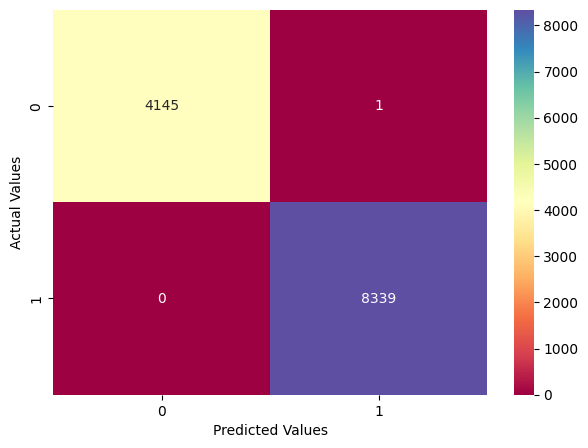

In [94]:
confusion_matrix_stats(rf_basic, X_train_scaled, y_train)

**Test**

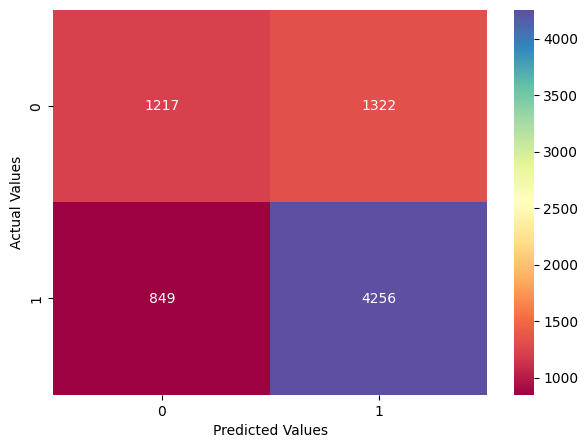

In [96]:
confusion_matrix_stats(rf_basic, X_test_scaled, y_test)

**Train**

In [98]:
basic_random_forest_classifier_train_perf = model_performance_stats(rf_basic, X_train_scaled, y_train)
basic_random_forest_classifier_train_perf

,Accuracy,Recall,Precision,F1
0,0.99992,1.0,0.99988,0.99994


**Test**

In [100]:
basic_random_forest_classifier_test_perf = model_performance_stats(rf_basic, X_test_scaled, y_test)
basic_random_forest_classifier_test_perf

,Accuracy,Recall,Precision,F1
0,0.715986,0.833692,0.762997,0.79678


**Train**

AUC: 1.00


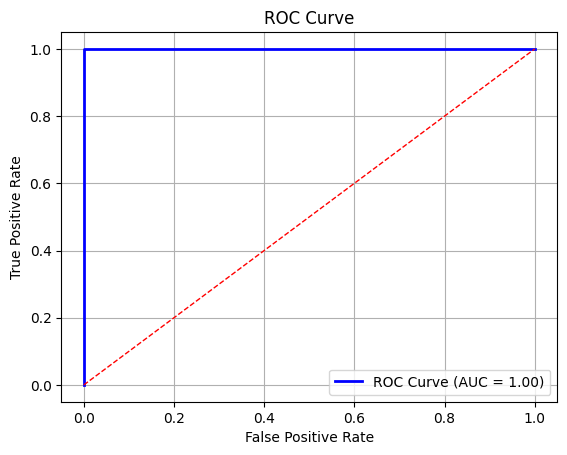

In [102]:
y_pred = rf_basic.predict_proba(X_train_scaled)[:,1]

fpr, tpr, threshold = roc_curve(y_train, y_pred)
roc_auc = auc(fpr, tpr)
print(f"AUC: {roc_auc:.2f}")


plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=1, linestyle='--') 
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

**Test**

AUC: 0.74


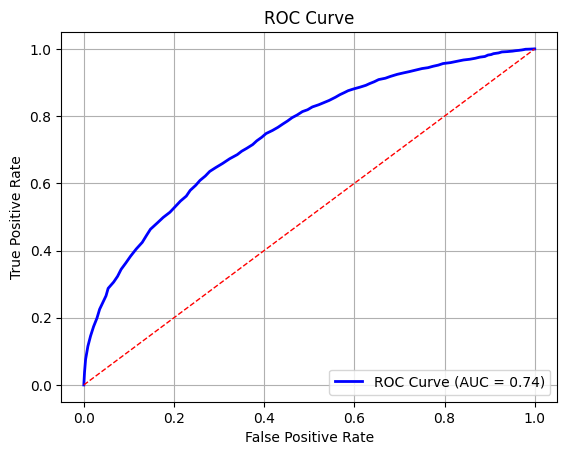

In [104]:
y_pred = rf_basic.predict_proba(X_test_scaled)[:,1]

fpr, tpr, threshold = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)
print(f"AUC: {roc_auc:.2f}")


plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=1, linestyle='--') 
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

## Ada-Boosting

In [106]:
ad_basic = AdaBoostClassifier(random_state= 42)

ad_basic.fit(X_train_scaled, y_train)

AdaBoostClassifier(random_state=42)

**Train**

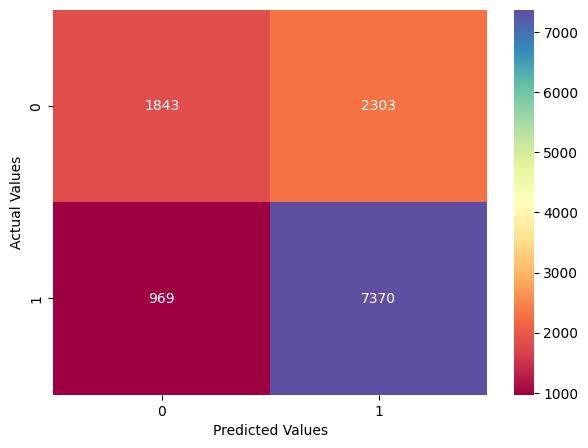

In [108]:
confusion_matrix_stats(ad_basic, X_train_scaled, y_train)

**Test**

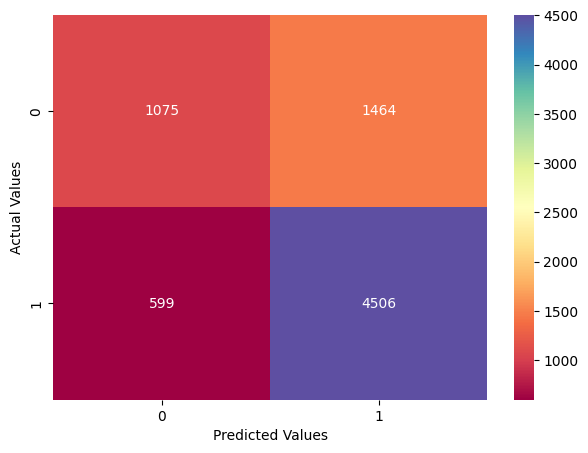

In [110]:
confusion_matrix_stats(ad_basic, X_test_scaled, y_test)

**Train**

In [112]:
ad_basic_model_train_perf = model_performance_stats(ad_basic, X_train_scaled, y_train)
ad_basic_model_train_perf

,Accuracy,Recall,Precision,F1
0,0.737926,0.883799,0.761915,0.818343


**Test**

In [1058]:
ad_basic_model_test_perf = model_performance_stats(ad_basic, X_test_scaled, y_test)
ad_basic_model_test_perf

,Accuracy,Recall,Precision,F1
0,0.730115,0.882664,0.754774,0.813725


**Train**

AUC: 0.78


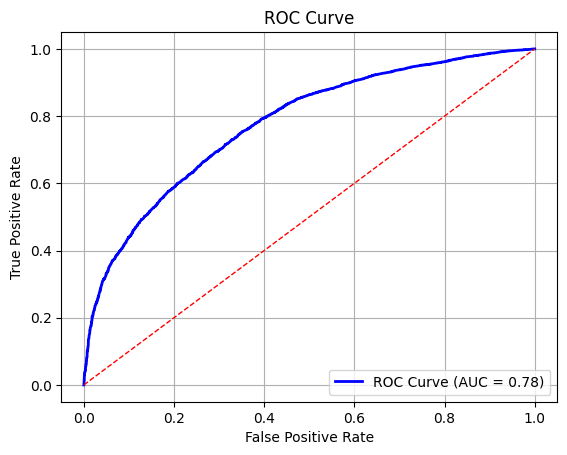

In [116]:
y_pred = ad_basic.predict_proba(X_train_scaled)[:,1]

fpr, tpr, threshold = roc_curve(y_train, y_pred)
roc_auc = auc(fpr, tpr)
print(f"AUC: {roc_auc:.2f}")


plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=1, linestyle='--') 
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

**Test**

AUC: 0.76


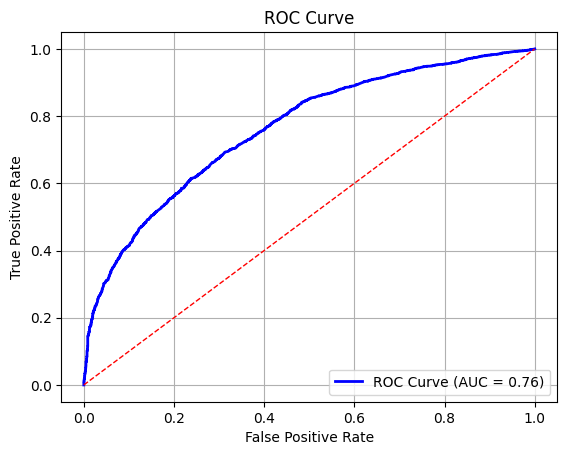

In [118]:
y_pred = ad_basic.predict_proba(X_test_scaled)[:,1]

fpr, tpr, threshold = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)
print(f"AUC: {roc_auc:.2f}")


plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=1, linestyle='--') 
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

## XGBoosting

In [120]:
XG_basic = XGBClassifier(random_state= 42)

XG_basic.fit(X_train_scaled, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

**Train**

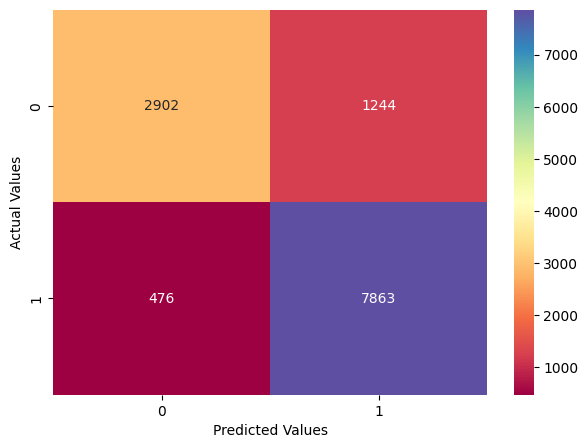

In [122]:
confusion_matrix_stats(XG_basic, X_train_scaled, y_train)

**Test**

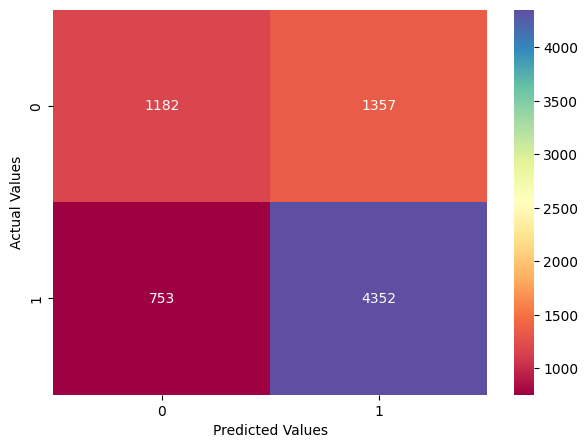

In [124]:
confusion_matrix_stats(XG_basic, X_test_scaled, y_test)

**Train**

In [126]:
xgb_basic_model_train_perf = model_performance_stats(XG_basic, X_train_scaled, y_train)
xgb_basic_model_train_perf

,Accuracy,Recall,Precision,F1
0,0.862235,0.942919,0.863402,0.90141


**Test**

In [128]:
xgb_basic_model_test_perf = model_performance_stats(XG_basic, X_test_scaled, y_test)
xgb_basic_model_test_perf

,Accuracy,Recall,Precision,F1
0,0.723967,0.852498,0.762305,0.804883


**Train**

AUC: 0.94


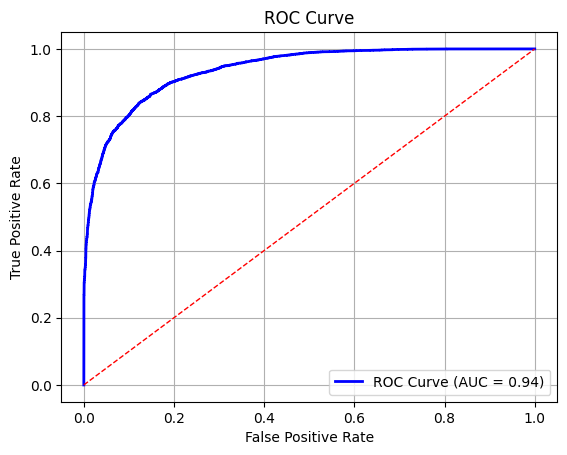

In [130]:
y_pred = XG_basic.predict_proba(X_train_scaled)[:,1]

fpr, tpr, threshold = roc_curve(y_train, y_pred)
roc_auc = auc(fpr, tpr)
print(f"AUC: {roc_auc:.2f}")


plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=1, linestyle='--') 
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

**Test**

AUC: 0.75


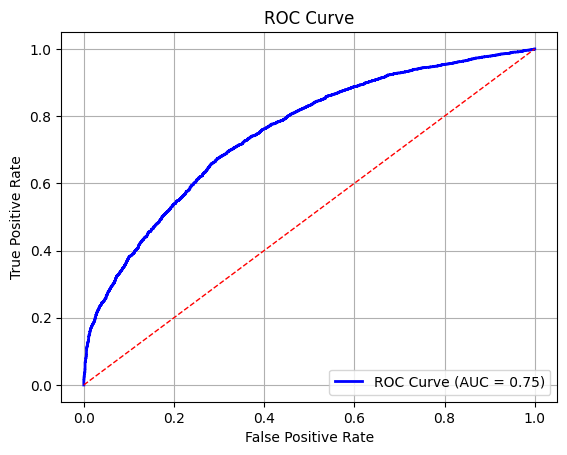

In [132]:
y_pred = XG_basic.predict_proba(X_test_scaled)[:,1]

fpr, tpr, threshold = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)
print(f"AUC: {roc_auc:.2f}")


plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=1, linestyle='--') 
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

## Model performance across different metrics (Original Data)

### Training performance comparison

In [135]:
models_train_comp_df = pd.concat(
    [
        decision_tree_default_perf_train.T,
        basic_bagging_classifier_train_perf.T,
        basic_random_forest_classifier_train_perf.T,
        ad_basic_model_train_perf.T,
        xgb_basic_model_train_perf.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Decision Tree Original",
    "Bagging Original",
    "Random Forest Original",
    "Ada-Boost Original",
    "XGBoost Original"
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Decision Tree Original,Bagging Original,Random Forest Original,Ada-Boost Original,XGBoost Original
Accuracy,1.0,0.986624,0.99992,0.737926,0.862235
Recall,1.0,0.987169,1.00000,0.883799,0.942919
Precision,1.0,0.992764,0.99988,0.761915,0.863402
F1,1.0,0.989959,0.99994,0.818343,0.901410


1. **Decision Tree Original**
    - Perfect scores across all metrics, likely overfitting the training data.
    - The training data too well and are likely to perform worse on unseen data.
  
2. **Bagging Original**
    - Very high performance, slightly below perfect.
    - Shows strong generalization on training data, but still a risk of overfitting.

3. **Random Forest Original**
    - Near-perfect performance, similar to Bagging.
    - Excellent balance of precision and recall.

4. **AdaBoost Original**
    - Much lower training accuracy (0.738) compared to ensemble methods.
    - Indicates less overfitting, but may underfit if not tuned.

5. **XGBoost Original**
    - Strong performance, especially in recall (0.943).
    - Slightly lower precision (0.863), suggesting more false positives.

### Test performance comparison

In [137]:
models_train_comp_df = pd.concat(
    [
        decision_tree_default_perf_test.T,
        basic_bagging_classifier_test_perf.T,
        basic_random_forest_classifier_test_perf.T,
        ad_basic_model_test_perf.T,
        xgb_basic_model_test_perf.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Decision Tree Original",
    "Bagging Original",
    "Random Forest Original",
    "Ada-Boost Original",
    "XGBoost Original"
]
print("Test performance comparison:")
models_train_comp_df

Test performance comparison:


,Decision Tree Original,Bagging Original,Random Forest Original,Ada-Boost Original,XGBoost Original
Accuracy,0.650052,0.693616,0.715986,0.730115,0.723967
Recall,0.732419,0.771988,0.833692,0.882664,0.852498
Precision,0.740689,0.769877,0.762997,0.754774,0.762305
F1,0.736531,0.770931,0.796780,0.813725,0.804883


1. **Decision Tree Original**
    - Lowest performance across all metrics.
    - Indicates overfitting during training and poor generalization.
  
2. **Bagging Original**
    - Moderate performance across all metrics.
    - Balanced but not leading in any metric.

3. **Random Forest Original**
    - Strong recall and F1, but slightly lower precision and accuracy than AdaBoost/XGBoost.
    - Still a solid performer.

4. **AdaBoost Original**
    - Best overall performer on test data.
    - Highest accuracy, recall, and F1 score.
    - Slightly lower precision, indicating more false positives, but excellent at identifying true positives.

5. **XGBoost Original**
    - Very close to AdaBoost in all metrics.
    - Slightly better precision than AdaBoost, but slightly lower recall and F1.

# <a name=link3>Model Building - Oversampled Data</a>

In [139]:
sm = SMOTE(random_state= 42)

X_train_over, y_train_over = sm.fit_resample(X_train_scaled, y_train)

In [140]:
print("Before OverSampling, count of label '1': {}".format(sum(y_train == 1)))
print("Before OverSampling, count of label '0': {} \n".format(sum(y_train == 0)))

print("After OverSampling, count of label '1': {}".format(sum(y_train_over == 1)))
print("After OverSampling, count of label '0': {} \n".format(sum(y_train_over == 0)))

print("After OverSampling, the shape of train_X: {}".format(X_train_over.shape))
print("After OverSampling, the shape of train_y: {} \n".format(y_train_over.shape))

Before OverSampling, count of label '1': 8339
Before OverSampling, count of label '0': 4146 

After OverSampling, count of label '1': 8339
After OverSampling, count of label '0': 8339 

After OverSampling, the shape of train_X: (16678, 21)
After OverSampling, the shape of train_y: (16678,) 



## Decision Tree

In [142]:
Dmodel_over = DecisionTreeClassifier(random_state= 42)

Dmodel_over.fit(X_train_over, y_train_over)

DecisionTreeClassifier(random_state=42)

**Train**

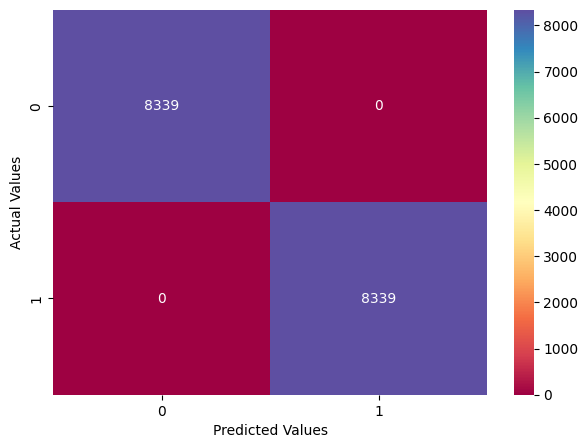

In [144]:
confusion_matrix_stats(Dmodel_over, X_train_over, y_train_over)

**Validation**

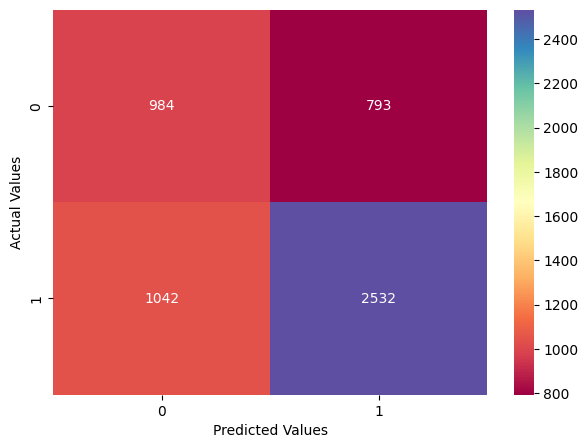

In [146]:
confusion_matrix_stats(Dmodel_over, X_val_scaled, y_val)

**Train**

In [148]:
decision_tree_Over_perf_train = model_performance_stats(Dmodel_over, X_train_over, y_train_over)
decision_tree_Over_perf_train

,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


**Validation**

In [150]:
decision_tree_Over_perf_Val = model_performance_stats(Dmodel_over, X_val_scaled, y_val)
decision_tree_Over_perf_Val

,Accuracy,Recall,Precision,F1
0,0.657073,0.70845,0.761504,0.734019


**Train**

AUC: 1.00


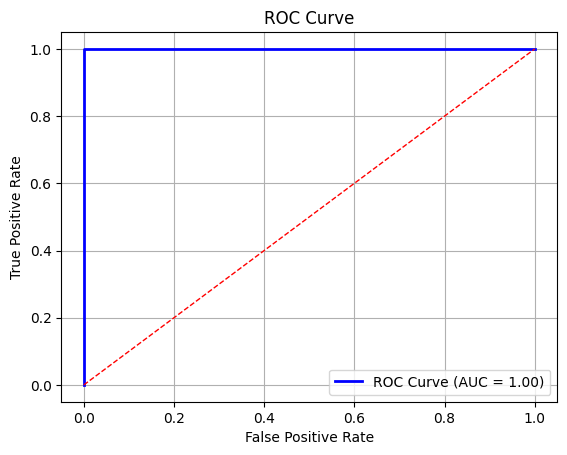

In [152]:
y_pred = Dmodel_over.predict_proba(X_train_over)[:,1]

fpr, tpr, threshold = roc_curve(y_train_over, y_pred)
roc_auc = auc(fpr, tpr)
print(f"AUC: {roc_auc:.2f}")


plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=1, linestyle='--') 
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

**Validation**

AUC: 0.63


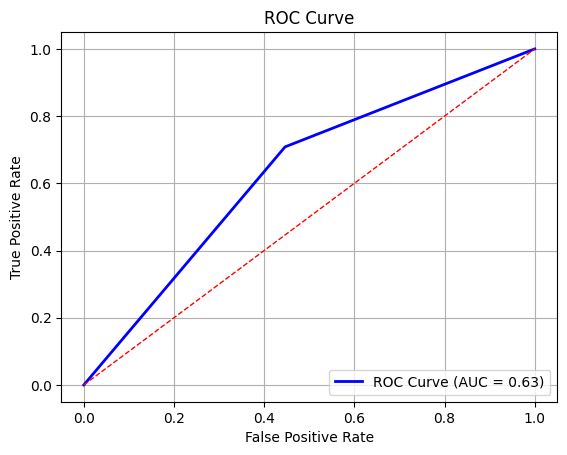

In [154]:
y_pred = Dmodel_over.predict_proba(X_val_scaled)[:,1]

fpr, tpr, threshold = roc_curve(y_val, y_pred)
roc_auc = auc(fpr, tpr)
print(f"AUC: {roc_auc:.2f}")


plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=1, linestyle='--') 
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

## Bagging

In [156]:
bagg_over = BaggingClassifier(
    estimator= DecisionTreeClassifier(),
    random_state= 42
)

bagg_over.fit(X_train_over, y_train_over)

BaggingClassifier(estimator=DecisionTreeClassifier(), random_state=42)

**Train**

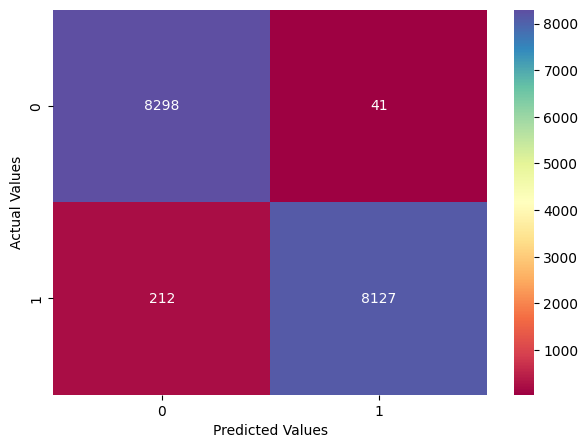

In [158]:
confusion_matrix_stats(bagg_over, X_train_over, y_train_over)

**Validation**

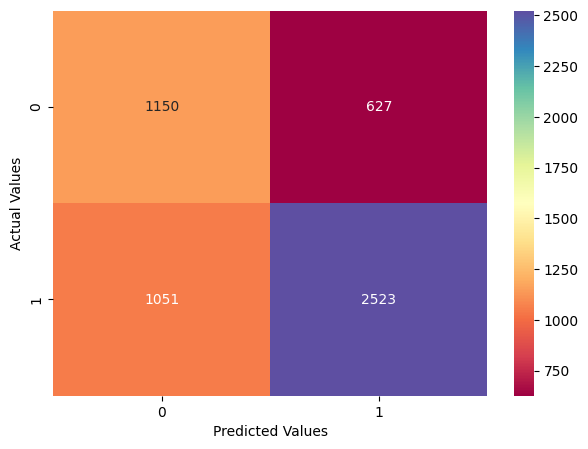

In [160]:
confusion_matrix_stats(bagg_over, X_val_scaled, y_val)

**Train**

In [162]:
Over_bagging_classifier_train_perf = model_performance_stats(bagg_over, X_train_over, y_train_over)
Over_bagging_classifier_train_perf

,Accuracy,Recall,Precision,F1
0,0.98483,0.974577,0.99498,0.984673


**Validation**

In [164]:
Over_bagging_classifier_val_perf = model_performance_stats(bagg_over, X_val_scaled, y_val)
Over_bagging_classifier_val_perf

,Accuracy,Recall,Precision,F1
0,0.686414,0.705932,0.800952,0.750446


**Train**

AUC: 1.00


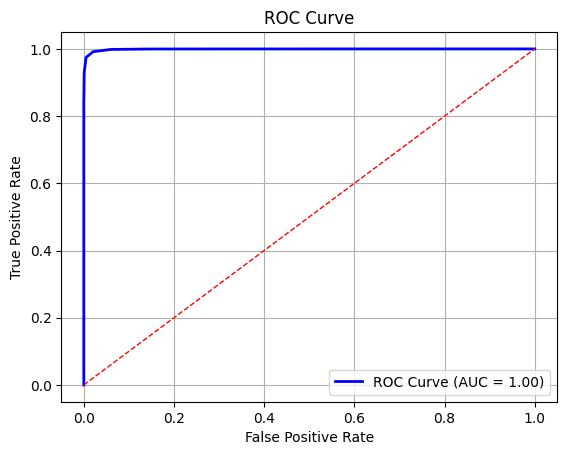

In [166]:
y_pred = bagg_over.predict_proba(X_train_over)[:,1]

fpr, tpr, threshold = roc_curve(y_train_over, y_pred)
roc_auc = auc(fpr, tpr)
print(f"AUC: {roc_auc:.2f}")


plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=1, linestyle='--') 
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

**Validation**

AUC: 0.73


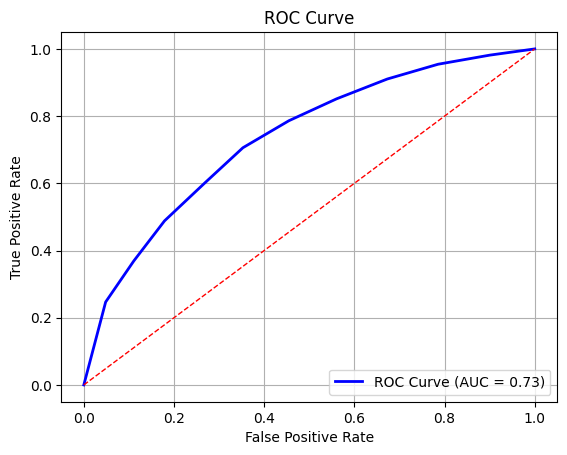

In [168]:
y_pred = bagg_over.predict_proba(X_val_scaled)[:,1]

fpr, tpr, threshold = roc_curve(y_val, y_pred)
roc_auc = auc(fpr, tpr)
print(f"AUC: {roc_auc:.2f}")


plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=1, linestyle='--') 
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

## Random Forest

In [170]:
rf_Over = RandomForestClassifier(random_state= 42)

rf_Over.fit(X_train_over, y_train_over)

RandomForestClassifier(random_state=42)

**Train**

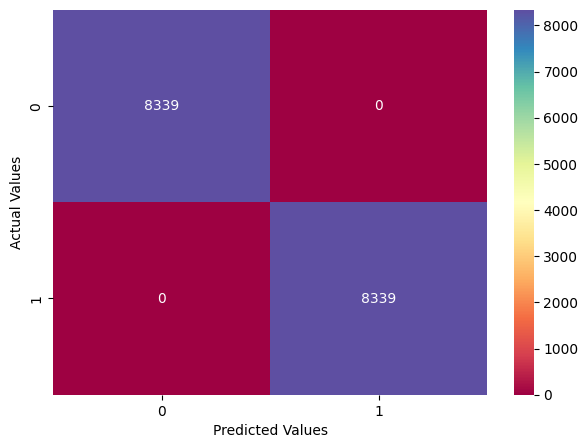

In [172]:
confusion_matrix_stats(rf_Over, X_train_over, y_train_over)

**Validation**

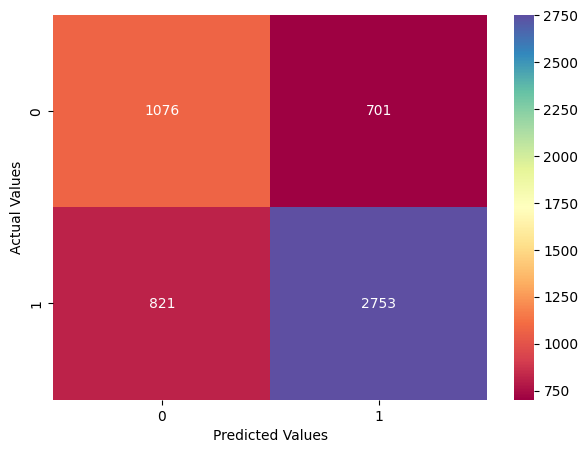

In [174]:
confusion_matrix_stats(rf_Over, X_val_scaled, y_val)

**Train**

In [176]:
Over_random_forest_classifier_train_perf = model_performance_stats(rf_Over, X_train_over, y_train_over)
Over_random_forest_classifier_train_perf

,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


**Validation**

In [178]:
Over_random_forest_classifier_Val_perf = model_performance_stats(rf_Over, X_val_scaled, y_val)
Over_random_forest_classifier_Val_perf

,Accuracy,Recall,Precision,F1
0,0.715567,0.770285,0.797047,0.783438


**Train**

AUC: 1.00


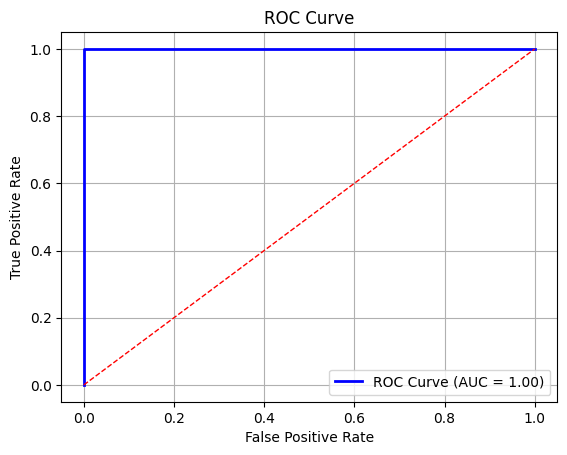

In [180]:
y_pred = rf_Over.predict_proba(X_train_over)[:,1]

fpr, tpr, threshold = roc_curve(y_train_over, y_pred)
roc_auc = auc(fpr, tpr)
print(f"AUC: {roc_auc:.2f}")


plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=1, linestyle='--') 
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

**Validation**

AUC: 0.76


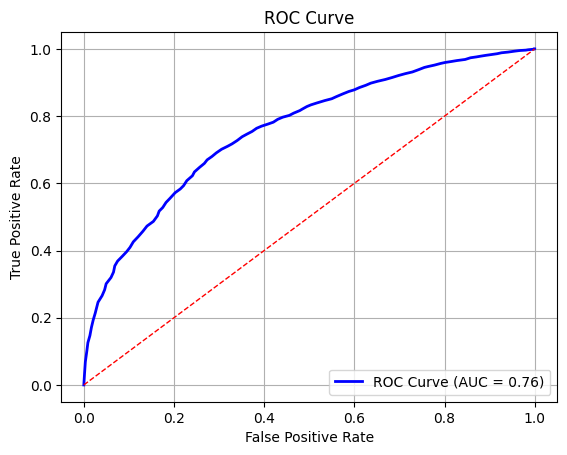

In [182]:
y_pred = rf_Over.predict_proba(X_val_scaled)[:,1]

fpr, tpr, threshold = roc_curve(y_val, y_pred)
roc_auc = auc(fpr, tpr)
print(f"AUC: {roc_auc:.2f}")


plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=1, linestyle='--') 
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

## Ada-Boosting

In [184]:
ad_Over = AdaBoostClassifier(random_state= 42)

ad_Over.fit(X_train_over, y_train_over)

AdaBoostClassifier(random_state=42)

**Train**

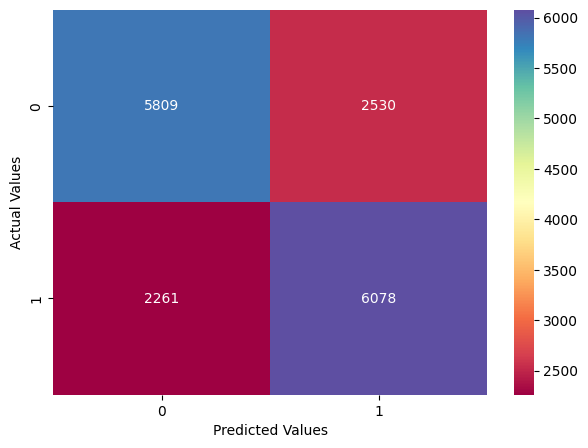

In [186]:
confusion_matrix_stats(ad_Over, X_train_over, y_train_over)

**Validation**

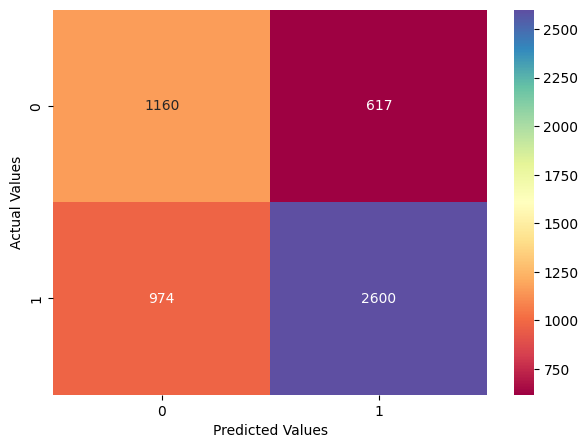

In [188]:
confusion_matrix_stats(ad_Over, X_val_scaled, y_val)

**Train**

In [190]:
ad_over_model_train_perf = model_performance_stats(ad_Over, X_train_over, y_train_over)
ad_over_model_train_perf

,Accuracy,Recall,Precision,F1
0,0.712735,0.728864,0.706087,0.717295


**Validation**

In [192]:
ad_over_model_val_perf = model_performance_stats(ad_Over, X_val_scaled, y_val)
ad_over_model_val_perf

,Accuracy,Recall,Precision,F1
0,0.702672,0.727476,0.808206,0.765719


**Train**

AUC: 0.79


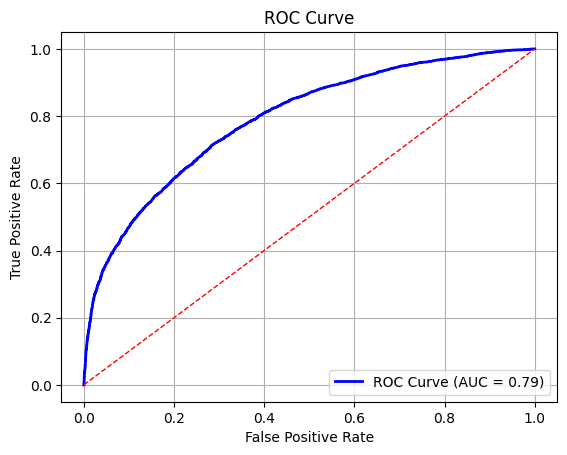

In [194]:
y_pred = ad_Over.predict_proba(X_train_over)[:,1]

fpr, tpr, threshold = roc_curve(y_train_over, y_pred)
roc_auc = auc(fpr, tpr)
print(f"AUC: {roc_auc:.2f}")


plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=1, linestyle='--') 
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

**Validation**

AUC: 0.76


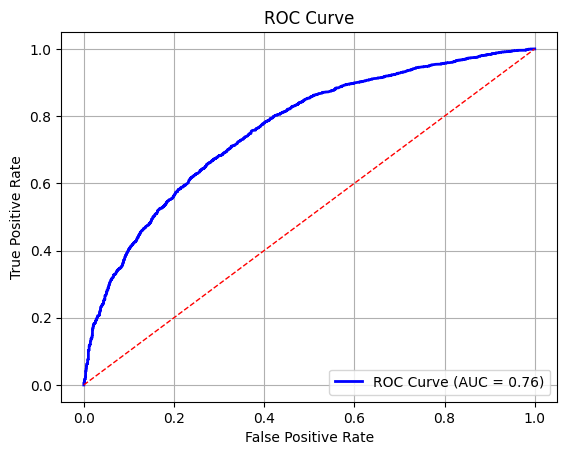

In [196]:
y_pred = ad_Over.predict_proba(X_val_scaled)[:,1]

fpr, tpr, threshold = roc_curve(y_val, y_pred)
roc_auc = auc(fpr, tpr)
print(f"AUC: {roc_auc:.2f}")


plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=1, linestyle='--') 
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

## XGBoosting

In [198]:
XG_Over = XGBClassifier(random_state= 42)

XG_Over.fit(X_train_over, y_train_over)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

**Train**

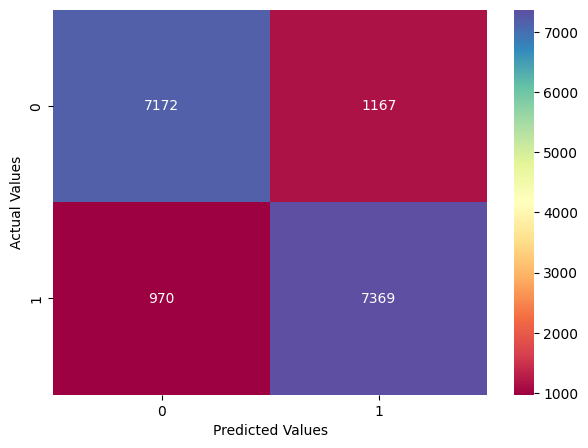

In [200]:
confusion_matrix_stats(XG_Over, X_train_over, y_train_over)

**Validation**

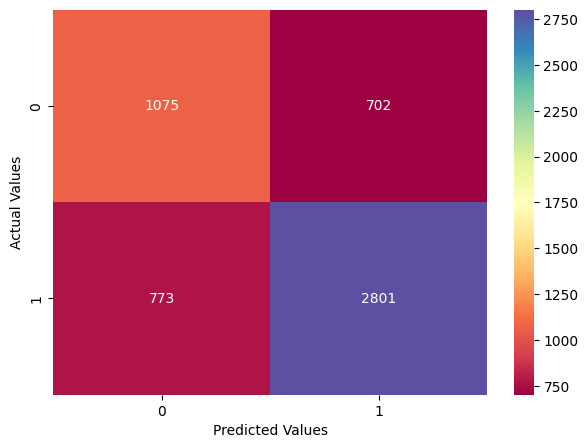

In [202]:
confusion_matrix_stats(XG_Over, X_val_scaled, y_val)

**Train**

In [204]:
xgb_over_model_train_perf = model_performance_stats(XG_Over, X_train_over, y_train_over)
xgb_over_model_train_perf

,Accuracy,Recall,Precision,F1
0,0.871867,0.883679,0.863285,0.873363


**Validation**

In [206]:
xgb_over_model_val_perf = model_performance_stats(XG_Over, X_val_scaled, y_val)
xgb_over_model_val_perf

,Accuracy,Recall,Precision,F1
0,0.724351,0.783716,0.7996,0.791578


**Train**

AUC: 0.95


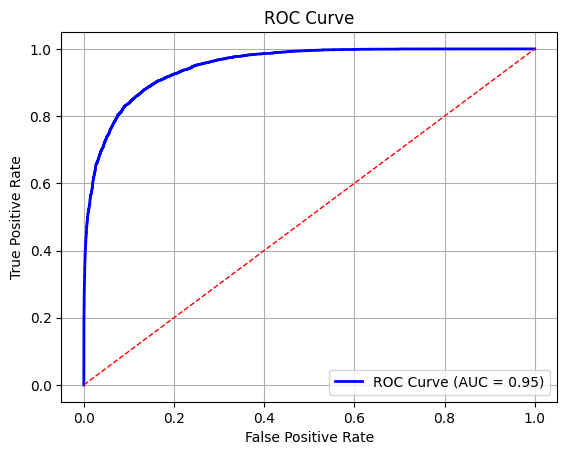

In [208]:
y_pred = XG_Over.predict_proba(X_train_over)[:,1]

fpr, tpr, threshold = roc_curve(y_train_over, y_pred)
roc_auc = auc(fpr, tpr)
print(f"AUC: {roc_auc:.2f}")


plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=1, linestyle='--') 
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

**Validation**

AUC: 0.76


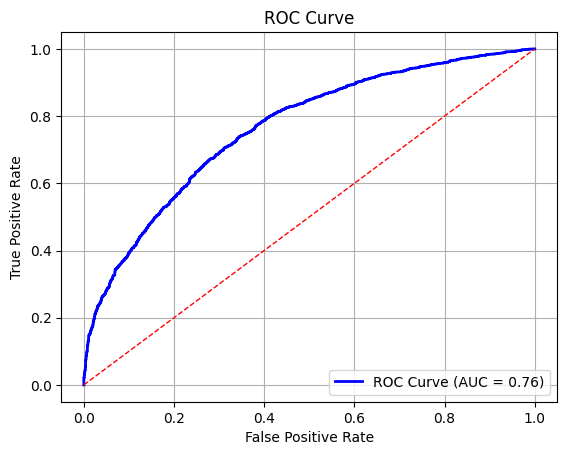

In [210]:
y_pred = XG_Over.predict_proba(X_val_scaled)[:,1]

fpr, tpr, threshold = roc_curve(y_val, y_pred)
roc_auc = auc(fpr, tpr)
print(f"AUC: {roc_auc:.2f}")


plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=1, linestyle='--') 
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

## Model performance across different metrics (OverSampled Data)

### Training performance comparison

In [213]:
models_train_comp_df = pd.concat(
    [
        decision_tree_Over_perf_train.T,
        Over_bagging_classifier_train_perf.T,
        Over_random_forest_classifier_train_perf.T,
        ad_over_model_train_perf.T,
        xgb_over_model_train_perf.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Decision Tree Oversample",
    "Bagging Oversample",
    "Random Forest Oversample",
    "Ada-Boost Oversample",
    "XGBoost Oversample"
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Decision Tree Oversample,Bagging Oversample,Random Forest Oversample,Ada-Boost Oversample,XGBoost Oversample
Accuracy,1.0,0.984830,1.0,0.712735,0.871867
Recall,1.0,0.974577,1.0,0.728864,0.883679
Precision,1.0,0.994980,1.0,0.706087,0.863285
F1,1.0,0.984673,1.0,0.717295,0.873363


1. **Decision Tree & Random Forest (Oversampled)**
    - Perfect scores across all metrics, clear signs of overfitting on the oversampled training data.
    - These models are memorizing the training set, which may not generalize well.
  
2. **Bagging Oversample**
    - Very high performance, slightly below perfect.
    - Strong generalization potential, but still at risk of overfitting.

3. **AdaBoost Oversample**
    - Much lower training metrics compared to others.
    - Indicates less overfitting, but may be underfitting or require tuning.

4. **XGBoost Oversample**
    - Balanced performance with high recall and precision.
    - Suggests good learning without extreme overfitting.

### Validation performance comparison

In [215]:
models_train_comp_df = pd.concat(
    [
        decision_tree_Over_perf_Val.T,
        Over_bagging_classifier_val_perf.T,
        Over_random_forest_classifier_Val_perf.T,
        ad_over_model_val_perf.T,
        xgb_over_model_val_perf.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Decision Tree Oversample",
    "Bagging Oversample",
    "Random Forest Oversample",
    "Ada-Boost Oversample",
    "XGBoost Oversample"
]
print("Validation performance comparison:")
models_train_comp_df

Validation performance comparison:


,Decision Tree Oversample,Bagging Oversample,Random Forest Oversample,Ada-Boost Oversample,XGBoost Oversample
Accuracy,0.657073,0.686414,0.715567,0.702672,0.724351
Recall,0.708450,0.705932,0.770285,0.727476,0.783716
Precision,0.761504,0.800952,0.797047,0.808206,0.799600
F1,0.734019,0.750446,0.783438,0.765719,0.791578


1. **Decision Tree Oversample**
    - Lowest performance across all metrics.
    - Suggests it doesn’t generalize well even with oversampling.

  
2. **Bagging Oversample**
    - Highest precision (0.801), but lower recall and F1.
    - Indicates a conservative model, good at being correct when it predicts positive, but misses more positives.

3. **Random Forest Oversample**
    - Second-best in F1 and recall.
    - Slightly lower accuracy than XGBoost but still strong.

4. **AdaBoost Oversample**
    - High precision (best among all), indicating fewer false positives.
    - Slightly lower recall and F1 than XGBoost and Random Forest.

5. **XGBoost Oversample**
    - Best overall performer across accuracy, recall, and F1 score.
    - Very strong balance between identifying true positives and minimizing false positives.

# <a name=link4>Model Building - Undersampled Data</a>

In [217]:
rus = RandomUnderSampler(random_state= 42)

X_train_un, y_train_un = rus.fit_resample(X_train_scaled, y_train)

In [218]:
print("Before Under Sampling, count of label '1': {}".format(sum(y_train == 1)))
print("Before Under Sampling, count of label '0': {} \n".format(sum(y_train == 0)))

print("After Under Sampling, count of label '1': {}".format(sum(y_train_un == 1)))
print("After Under Sampling, count of label '0': {} \n".format(sum(y_train_un == 0)))

print("After Under Sampling, the shape of train_X: {}".format(X_train_un.shape))
print("After Under Sampling, the shape of train_y: {} \n".format(y_train_un.shape))

Before Under Sampling, count of label '1': 8339
Before Under Sampling, count of label '0': 4146 

After Under Sampling, count of label '1': 4146
After Under Sampling, count of label '0': 4146 

After Under Sampling, the shape of train_X: (8292, 21)
After Under Sampling, the shape of train_y: (8292,) 



## Decision Tree

In [220]:
Dmodel_un = DecisionTreeClassifier(random_state= 42)

Dmodel_un.fit(X_train_un, y_train_un)

DecisionTreeClassifier(random_state=42)

**Train**

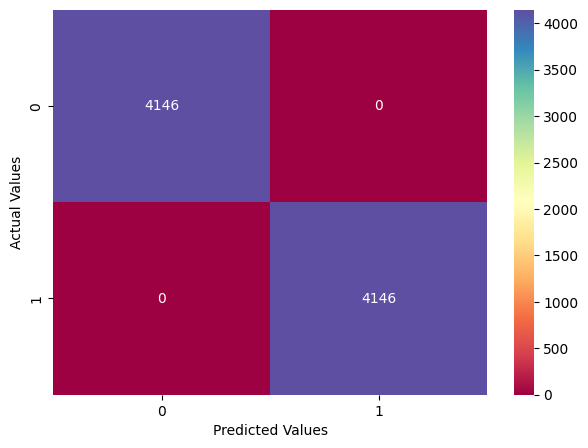

In [222]:
confusion_matrix_stats(Dmodel_un, X_train_un, y_train_un)

**Validation**

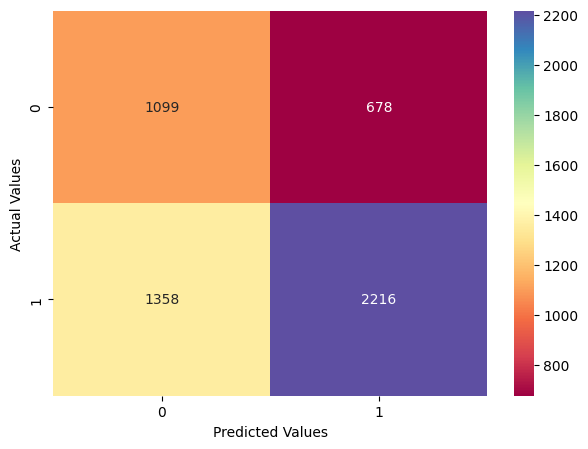

In [224]:
confusion_matrix_stats(Dmodel_un, X_val_scaled, y_val)

**Train**

In [226]:
decision_tree_Under_perf_train = model_performance_stats(Dmodel_un, X_train_un, y_train_un)
decision_tree_Under_perf_train

,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


**Validation**

In [228]:
decision_tree_Under_perf_Val = model_performance_stats(Dmodel_un, X_val_scaled, y_val)
decision_tree_Under_perf_Val

,Accuracy,Recall,Precision,F1
0,0.61951,0.620034,0.765722,0.68522


**Train**

AUC: 1.00


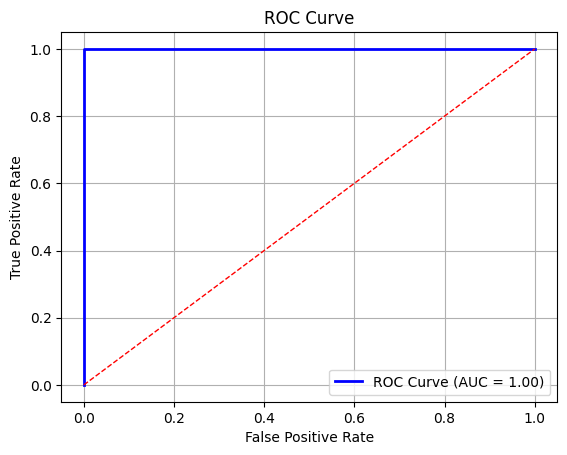

In [230]:
y_pred = Dmodel_un.predict_proba(X_train_un)[:,1]

fpr, tpr, threshold = roc_curve(y_train_un, y_pred)
roc_auc = auc(fpr, tpr)
print(f"AUC: {roc_auc:.2f}")


plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=1, linestyle='--') 
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

**Validation**

AUC: 0.62


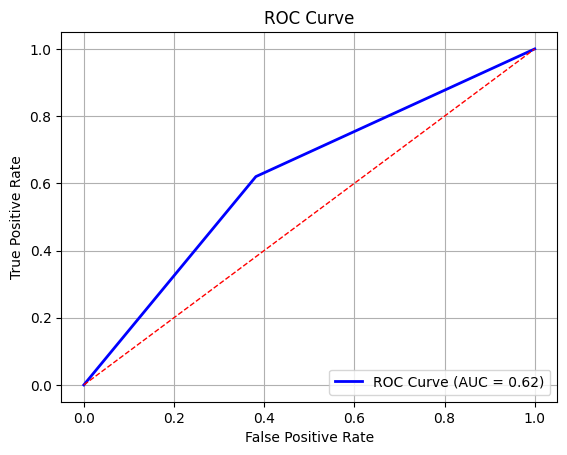

In [232]:
y_pred = Dmodel_un.predict_proba(X_val_scaled)[:,1]

fpr, tpr, threshold = roc_curve(y_val, y_pred)
roc_auc = auc(fpr, tpr)
print(f"AUC: {roc_auc:.2f}")


plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=1, linestyle='--') 
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

## Bagging

In [234]:
bagg_un = BaggingClassifier(
    estimator= DecisionTreeClassifier(),
    random_state= 42
)

bagg_un.fit(X_train_un, y_train_un)

BaggingClassifier(estimator=DecisionTreeClassifier(), random_state=42)

**Train**

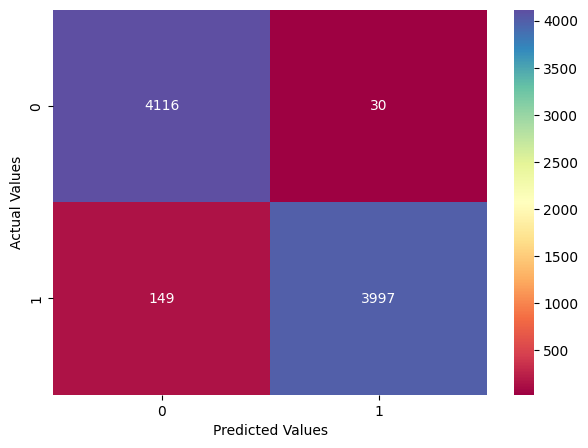

In [236]:
confusion_matrix_stats(bagg_un, X_train_un, y_train_un)

**Validation**

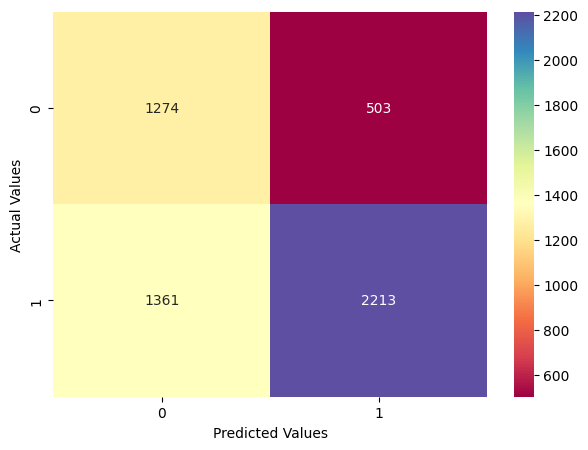

In [238]:
confusion_matrix_stats(bagg_un, X_val_scaled, y_val)

**Train**

In [240]:
Under_bagging_classifier_train_perf = model_performance_stats(bagg_un, X_train_un, y_train_un)
Under_bagging_classifier_train_perf

,Accuracy,Recall,Precision,F1
0,0.978413,0.964062,0.99255,0.978099


**Validation**

In [242]:
Under_bagging_classifier_val_perf = model_performance_stats(bagg_un, X_val_scaled, y_val)
Under_bagging_classifier_val_perf

,Accuracy,Recall,Precision,F1
0,0.651654,0.619194,0.814801,0.703657


**Train**

AUC: 1.00


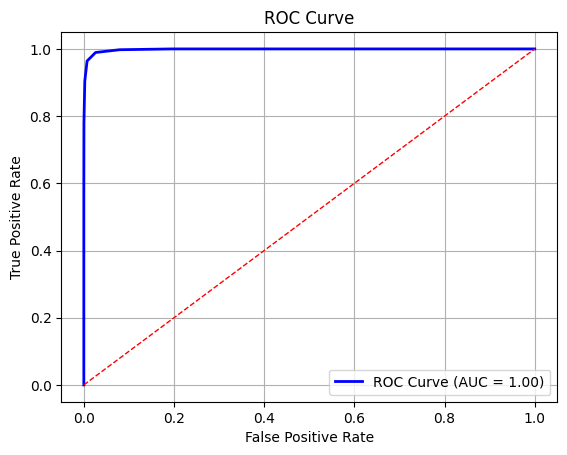

In [244]:
y_pred = bagg_un.predict_proba(X_train_un)[:,1]

fpr, tpr, threshold = roc_curve(y_train_un, y_pred)
roc_auc = auc(fpr, tpr)
print(f"AUC: {roc_auc:.2f}")


plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=1, linestyle='--') 
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

**Validation**

AUC: 0.74


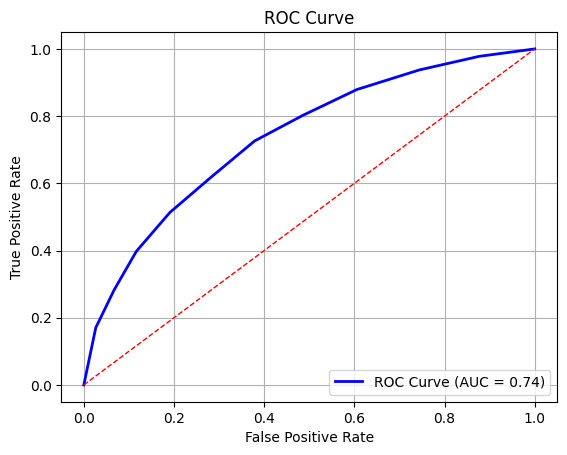

In [246]:
y_pred = bagg_un.predict_proba(X_val_scaled)[:,1]

fpr, tpr, threshold = roc_curve(y_val, y_pred)
roc_auc = auc(fpr, tpr)
print(f"AUC: {roc_auc:.2f}")


plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=1, linestyle='--') 
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

## Random Forest

In [248]:
rf_un = RandomForestClassifier(random_state= 42)

rf_un.fit(X_train_un, y_train_un)

RandomForestClassifier(random_state=42)

**Train**

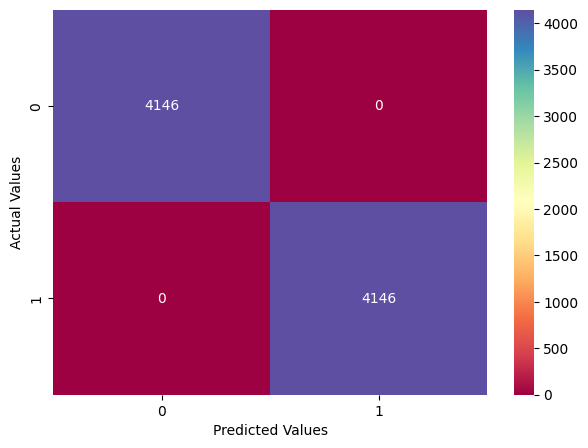

In [250]:
confusion_matrix_stats(rf_un, X_train_un, y_train_un)

**Validation**

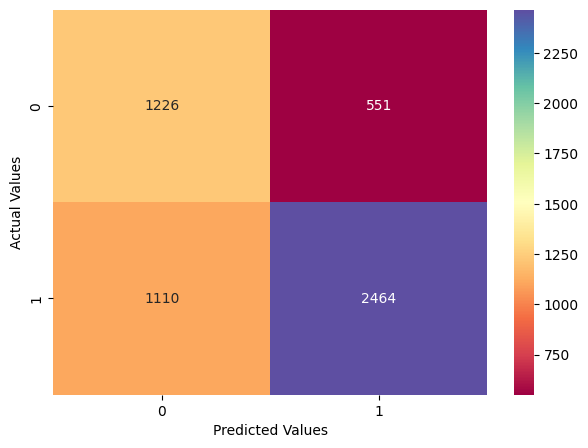

In [252]:
confusion_matrix_stats(rf_un, X_val_scaled, y_val)

**Train**

In [254]:
Under_random_forest_classifier_train_perf = model_performance_stats(rf_un, X_train_un, y_train_un)
Under_random_forest_classifier_train_perf

,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


**Validation**

In [256]:
Under_random_forest_classifier_Val_perf = model_performance_stats(rf_un, X_val_scaled, y_val)
Under_random_forest_classifier_Val_perf

,Accuracy,Recall,Precision,F1
0,0.689591,0.689424,0.817247,0.747913


**Train**

AUC: 1.00


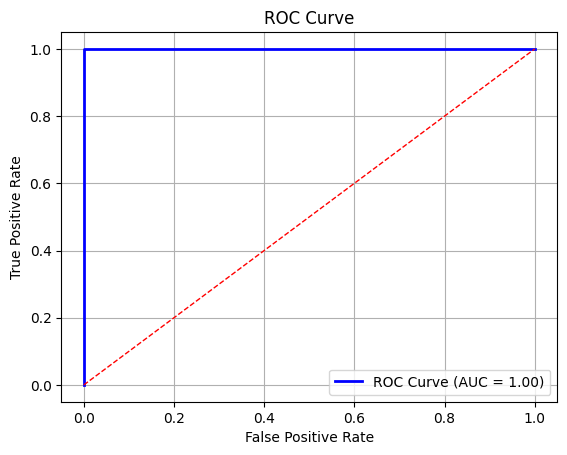

In [258]:
y_pred = rf_un.predict_proba(X_train_un)[:,1]

fpr, tpr, threshold = roc_curve(y_train_un, y_pred)
roc_auc = auc(fpr, tpr)
print(f"AUC: {roc_auc:.2f}")


plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=1, linestyle='--') 
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

**Validation**

AUC: 0.76


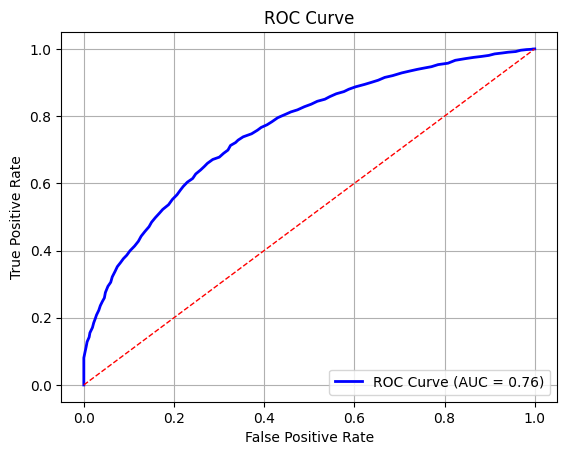

In [260]:
y_pred = rf_un.predict_proba(X_val_scaled)[:,1]

fpr, tpr, threshold = roc_curve(y_val, y_pred)
roc_auc = auc(fpr, tpr)
print(f"AUC: {roc_auc:.2f}")


plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=1, linestyle='--') 
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

## Ada-Boosting

In [262]:
ad_un = AdaBoostClassifier(random_state= 42)

ad_un.fit(X_train_un, y_train_un)

AdaBoostClassifier(random_state=42)

**Train**

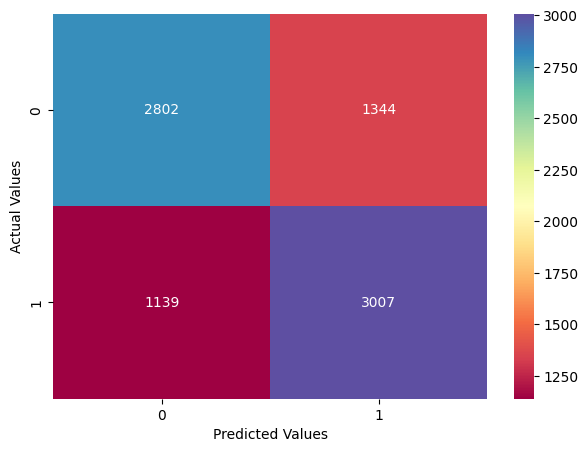

In [264]:
confusion_matrix_stats(ad_un, X_train_un, y_train_un)

**Validation**

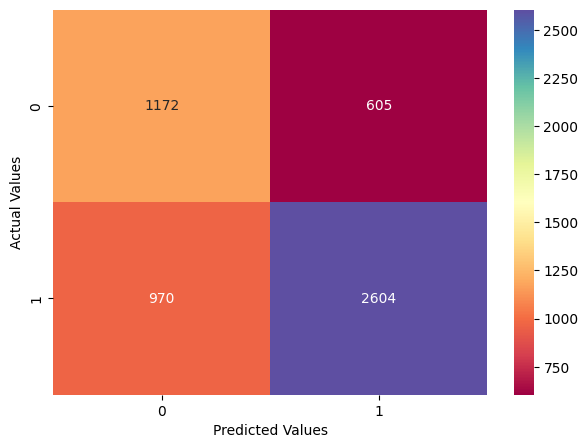

In [266]:
confusion_matrix_stats(ad_un, X_val_scaled, y_val)

**Train**

In [268]:
ad_under_model_train_perf = model_performance_stats(ad_un, X_train_un, y_train_un)
ad_under_model_train_perf

,Accuracy,Recall,Precision,F1
0,0.700555,0.725277,0.691105,0.707779


**Validation**

In [270]:
ad_under_model_val_perf = model_performance_stats(ad_un, X_val_scaled, y_val)
ad_under_model_val_perf

,Accuracy,Recall,Precision,F1
0,0.705662,0.728595,0.811468,0.767802


**Train**

AUC: 0.78


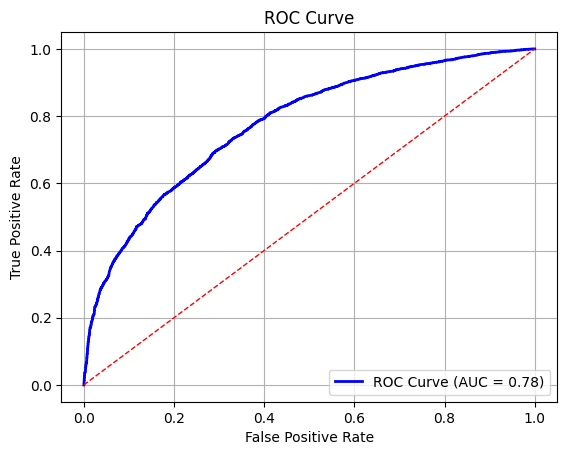

In [272]:
y_pred = ad_un.predict_proba(X_train_un)[:,1]

fpr, tpr, threshold = roc_curve(y_train_un, y_pred)
roc_auc = auc(fpr, tpr)
print(f"AUC: {roc_auc:.2f}")


plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=1, linestyle='--') 
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

**Validation**

AUC: 0.77


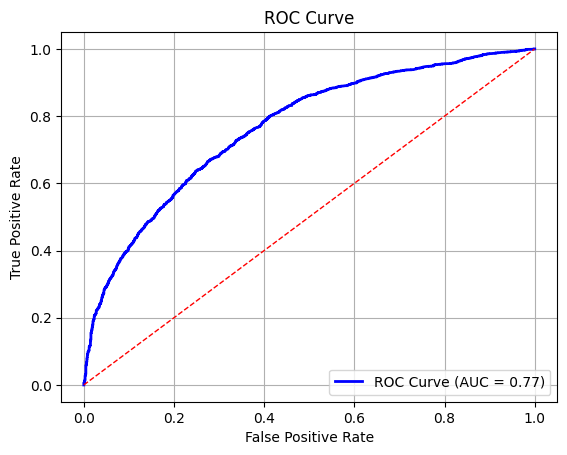

In [274]:
y_pred = ad_un.predict_proba(X_val_scaled)[:,1]

fpr, tpr, threshold = roc_curve(y_val, y_pred)
roc_auc = auc(fpr, tpr)
print(f"AUC: {roc_auc:.2f}")


plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=1, linestyle='--') 
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

## XGBoosting

In [276]:
XG_un = XGBClassifier(random_state= 42)

XG_un.fit(X_train_un, y_train_un)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

**Train**

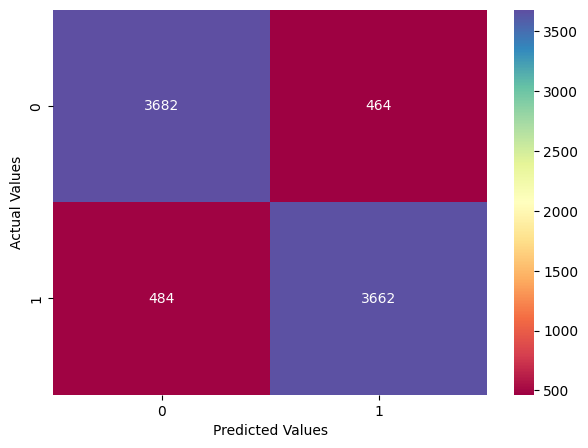

In [278]:
confusion_matrix_stats(XG_un, X_train_un, y_train_un)

**Validation**

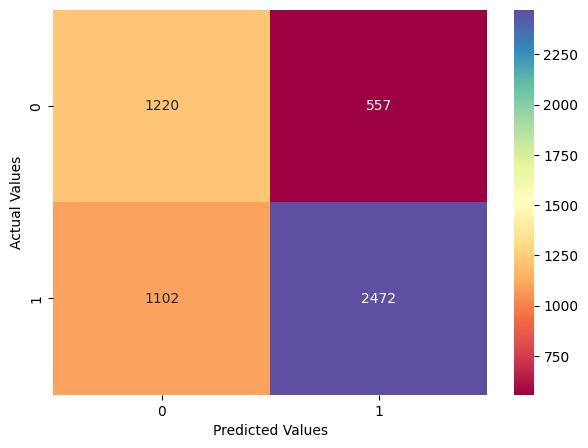

In [280]:
confusion_matrix_stats(XG_un, X_val_scaled, y_val)

**Train**

In [282]:
xgb_under_model_train_perf = model_performance_stats(XG_un, X_train_un, y_train_un)
xgb_under_model_train_perf

,Accuracy,Recall,Precision,F1
0,0.885673,0.883261,0.887542,0.885397


**Validation**

In [284]:
xgb_under_model_val_perf = model_performance_stats(XG_un, X_val_scaled, y_val)
xgb_under_model_val_perf

,Accuracy,Recall,Precision,F1
0,0.689964,0.691662,0.816111,0.748751


**Train**

AUC: 0.96


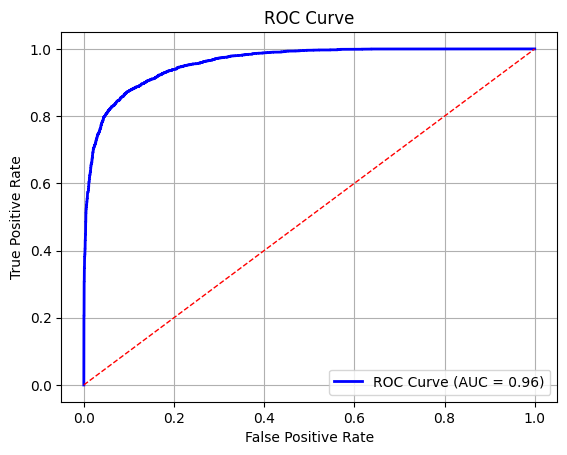

In [286]:
y_pred = XG_un.predict_proba(X_train_un)[:,1]

fpr, tpr, threshold = roc_curve(y_train_un, y_pred)
roc_auc = auc(fpr, tpr)
print(f"AUC: {roc_auc:.2f}")


plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=1, linestyle='--') 
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

**Validation**

AUC: 0.75


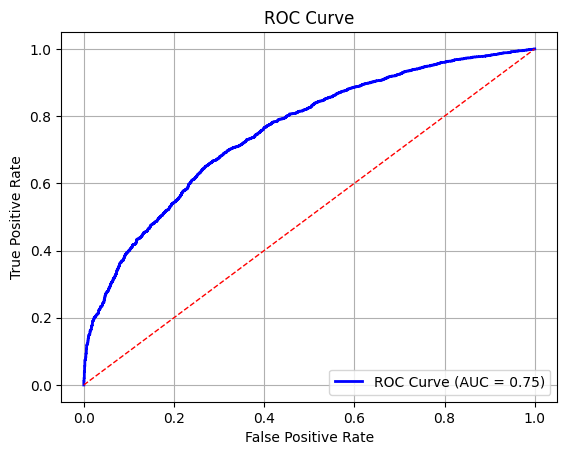

In [288]:
y_pred = XG_un.predict_proba(X_val_scaled)[:,1]

fpr, tpr, threshold = roc_curve(y_val, y_pred)
roc_auc = auc(fpr, tpr)
print(f"AUC: {roc_auc:.2f}")


plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=1, linestyle='--') 
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

## Model performance across different metrics (Undersampled Data)

### Training performance comparison

In [291]:
models_train_comp_df = pd.concat(
    [
        decision_tree_Under_perf_train.T,
        Under_bagging_classifier_train_perf.T,
        Under_random_forest_classifier_train_perf.T,
        ad_under_model_train_perf.T,
        xgb_under_model_train_perf.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Decision Tree Undersample",
    "Bagging Undersample",
    "Random Forest Undersample",
    "Ada-Boost Undersample",
    "XGBoost Undersample"
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Decision Tree Undersample,Bagging Undersample,Random Forest Undersample,Ada-Boost Undersample,XGBoost Undersample
Accuracy,1.0,0.978413,1.0,0.700555,0.885673
Recall,1.0,0.964062,1.0,0.725277,0.883261
Precision,1.0,0.992550,1.0,0.691105,0.887542
F1,1.0,0.978099,1.0,0.707779,0.885397


1. **Decision Tree, Random Forest, AdaBoost (Undersampled)**
    - All show perfect training scores — 100% across accuracy, recall, and precision.
    - This is a strong indicator of overfitting, especially concerning with undersampled data, which reduces the diversity of training examples.
  
2. **Bagging Undersample**
    - Very high performance, but not perfect — slightly more realistic.
    - Still at risk of overfitting, but potentially more generalizable than the others.

3. **XGBoost Undersample**
    - Significantly lower training performance compared to others.
    - Accuracy: 70%, Recall: 72.5%, Precision: 69.1%.
    - Indicates less overfitting and possibly better generalization.


### Validation performance comparison

In [293]:
models_train_comp_df = pd.concat(
    [
        decision_tree_Under_perf_Val.T,
        Under_bagging_classifier_val_perf.T,
        Under_random_forest_classifier_Val_perf.T,
        ad_under_model_val_perf.T,
        xgb_under_model_val_perf.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Decision Tree Undersample",
    "Bagging Undersample",
    "Random Forest Undersample",
    "Ada-Boost Undersample",
    "XGBoost Undersample"
]
print("Validation performance comparison:")
models_train_comp_df

Validation performance comparison:


,Decision Tree Undersample,Bagging Undersample,Random Forest Undersample,Ada-Boost Undersample,XGBoost Undersample
Accuracy,0.619510,0.651654,0.689591,0.705662,0.689964
Recall,0.620034,0.619194,0.689424,0.728595,0.691662
Precision,0.765722,0.814801,0.817247,0.811468,0.816111
F1,0.685220,0.703657,0.747913,0.767802,0.748751


1. **Decision Tree Undersample**
    - Lowest performance across all metrics.
    - Suggests poor generalization and limited learning from undersampled data.
      
2. **Bagging Undersample**
    - Highest precision (0.815), but lower recall (0.619).
    - Indicates a conservative model, good at being correct when it predicts positive, but misses more positives.

3. **Random Forest Undersample**
    - Balanced performance, slightly behind XGBoost and AdaBoost.
    - Strong precision and recall, making it a reliable choice.

4. **AdaBoost Undersample**
    - Best overall performer in accuracy, recall, and F1 score.
    - Indicates strong generalization and ability to identify true positives.

5. **XGBoost Undersample**
    - Very close to AdaBoost in all metrics.
    - Slightly lower recall but nearly identical F1 and precision.

**Oversample data outperforms undersample data, so we will use it for model tuning.**

# <a name=link5>Model Performance Improvement using Hyperparameter Tuning</a>

## Decision Tree Hyperparameter Tuning Using GridSearchCV

In [296]:
parameters = {
    'max_depth': [3, 5, 7, 9, 12],
    'min_samples_split': [2, 5, 10, 20],
    'max_leaf_nodes': [10, 20, 30, 50],
    "class_weight": ['balanced', None] 
}

In [297]:
%%time

dtree = DecisionTreeClassifier(random_state= 42)

grid_obj = GridSearchCV(
    estimator= dtree,
    param_grid= parameters,
    scoring= 'f1',
    cv= 5,
    n_jobs= -1,
)

grid_obj.fit(X_train_over, y_train_over)

CPU times: total: 11.8 s
Wall time: 34.3 s


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'class_weight': ['balanced', None],
                         'max_depth': [3, 5, 7, 9, 12],
                         'max_leaf_nodes': [10, 20, 30, 50],
                         'min_samples_split': [2, 5, 10, 20]},
             scoring='f1')

In [298]:
dtree_tuned = grid_obj.best_estimator_
print(dtree_tuned)

DecisionTreeClassifier(class_weight='balanced', max_depth=12, max_leaf_nodes=30,
                       random_state=42)


**Train**

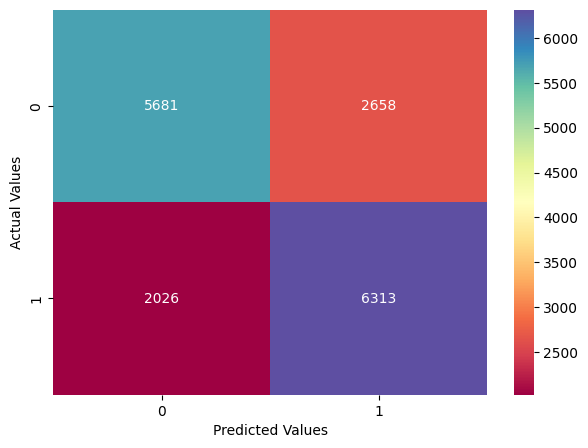

In [300]:
confusion_matrix_stats(dtree_tuned, X_train_over, y_train_over)

**Validation**

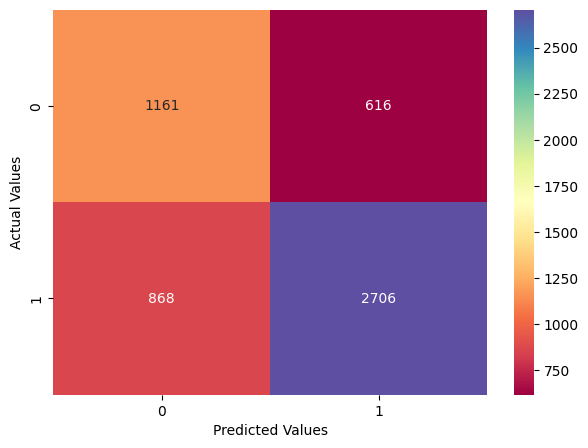

In [302]:
confusion_matrix_stats(dtree_tuned, X_val_scaled, y_val)

**Train**

In [304]:
decision_tree_tuned_perf_train = model_performance_stats(dtree_tuned, X_train_over, y_train_over)
decision_tree_tuned_perf_train

,Accuracy,Recall,Precision,F1
0,0.719151,0.757045,0.703712,0.729405


**Validation**

In [306]:
decision_tree_tuned_perf_val = model_performance_stats(dtree_tuned, X_val_scaled, y_val)
decision_tree_tuned_perf_val

,Accuracy,Recall,Precision,F1
0,0.722669,0.757135,0.81457,0.784803


**Train**

AUC: 0.75


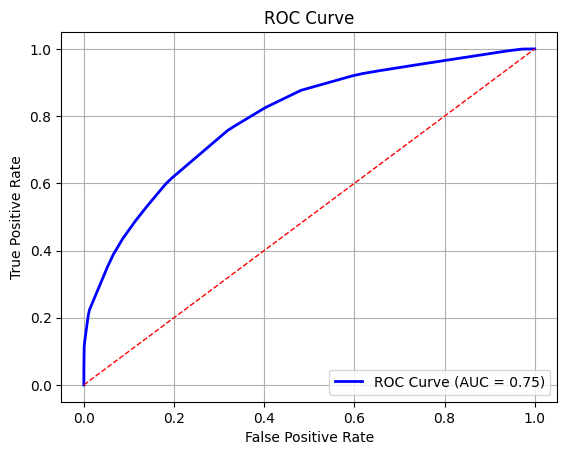

In [308]:
y_pred = dtree_tuned.predict_proba(X_train_over)[:,1]

fpr, tpr, threshold = roc_curve(y_train_over, y_pred)
print(f"AUC: {roc_auc:.2f}")


plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=1, linestyle='--') 
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

**Validation**

AUC: 0.75


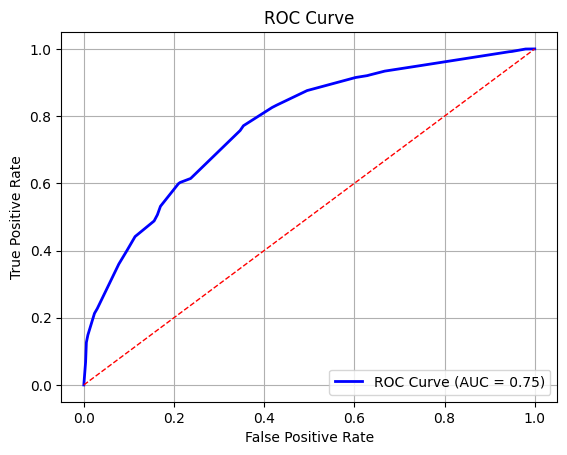

In [310]:
y_pred = dtree_tuned.predict_proba(X_val_scaled)[:,1]

fpr, tpr, threshold = roc_curve(y_val, y_pred)
print(f"AUC: {roc_auc:.2f}")


plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=1, linestyle='--') 
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

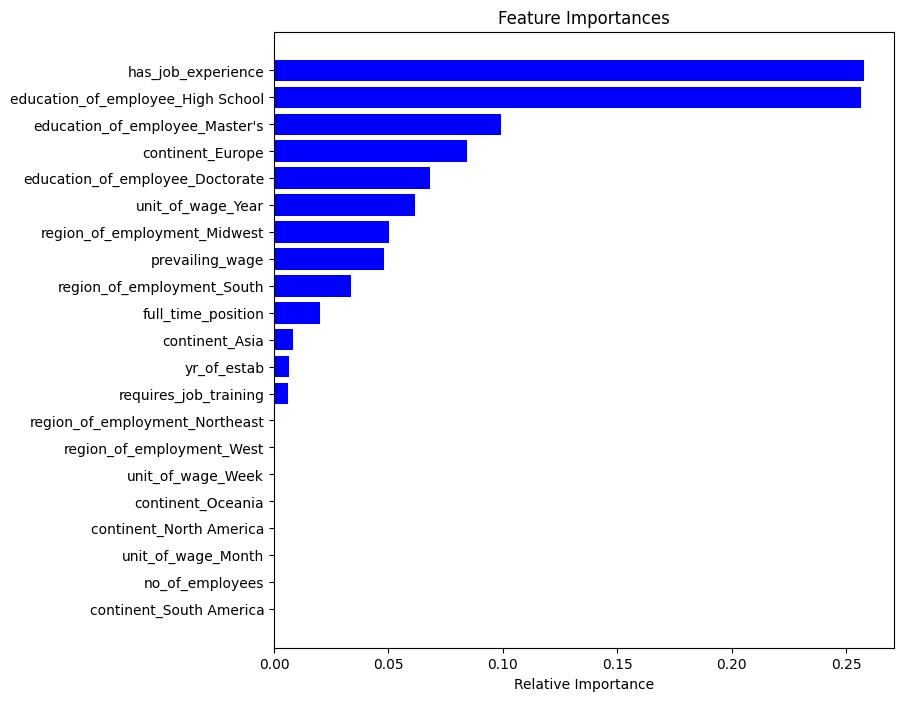

In [977]:
feature_names = list(X_train.columns)

importances = dtree_tuned.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8, 8))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="blue", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

## Bagging Hyperparameter Tuning Using GridSearchCV

In [1001]:
parameters_bagg = {
    'n_estimators': [50, 75, 100, 150],
    'max_samples': [0.3, 0.5, 0.7],
    'estimator__max_depth': [5, 8, 10, 12, 15],
    'estimator__min_samples_split': [5, 10, 15, 20],
    'estimator__criterion': ['gini', 'entropy']
}

In [1005]:
%%time

bagg_model = BaggingClassifier(estimator= DecisionTreeClassifier(), random_state= 42)

grid_obj_bagg = GridSearchCV(
    estimator= bagg_model,
    param_grid= parameters_bagg,
    cv= 5,
    scoring= 'f1',
    n_jobs= -1,
)

grid_obj_bagg.fit(X_train_over, y_train_over)

CPU times: total: 43.5 s
Wall time: 56min 45s


GridSearchCV(cv=5,
             estimator=BaggingClassifier(estimator=DecisionTreeClassifier(),
                                         random_state=42),
             n_jobs=-1,
             param_grid={'estimator__criterion': ['gini', 'entropy'],
                         'estimator__max_depth': [5, 8, 10, 12, 15],
                         'estimator__min_samples_split': [5, 10, 15, 20],
                         'max_samples': [0.3, 0.5, 0.7],
                         'n_estimators': [50, 75, 100, 150]},
             scoring='f1')

In [1007]:
bagg_tuned = grid_obj_bagg.best_estimator_
print(bagg_tuned)

BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=15,
                                                   min_samples_split=5),
                  max_samples=0.7, n_estimators=75, random_state=42)


**Train**

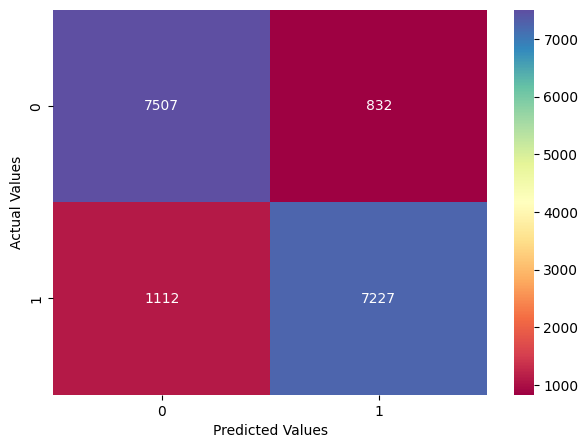

In [1010]:
confusion_matrix_stats(bagg_tuned, X_train_over, y_train_over)

**Validation**

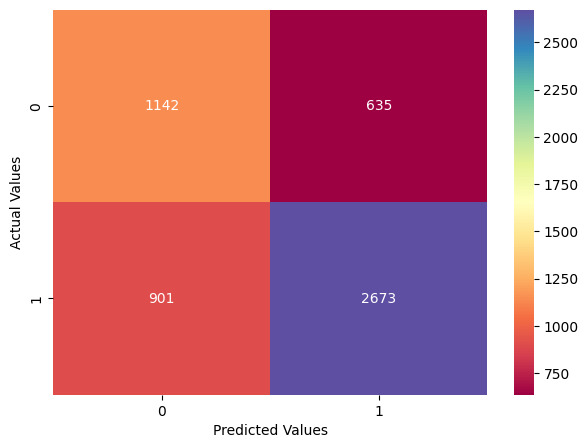

In [1013]:
confusion_matrix_stats(bagg_tuned, X_val_scaled, y_val)

**Train**

In [1016]:
Bagging_tuned_perf_train = model_performance_stats(bagg_tuned, X_train_over, y_train_over)
Bagging_tuned_perf_train

,Accuracy,Recall,Precision,F1
0,0.883439,0.866651,0.896761,0.881449


**Validation**

In [1019]:
Bagging_tuned_perf_val = model_performance_stats(bagg_tuned, X_val_scaled, y_val)
Bagging_tuned_perf_val

,Accuracy,Recall,Precision,F1
0,0.712951,0.747902,0.808041,0.776809


**Train**

AUC: 0.75


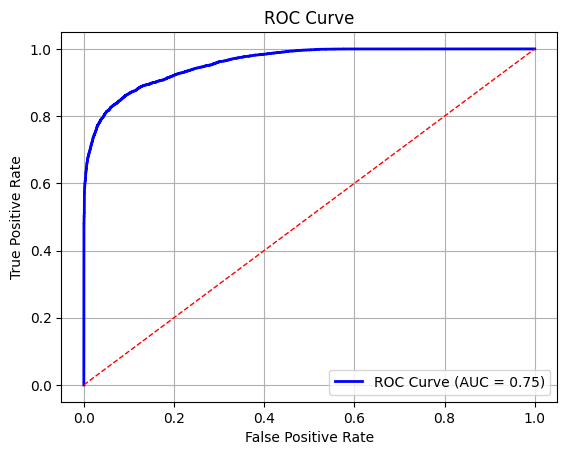

In [1022]:
y_pred = bagg_tuned.predict_proba(X_train_over)[:,1]

fpr, tpr, threshold = roc_curve(y_train_over, y_pred)
print(f"AUC: {roc_auc:.2f}")


plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=1, linestyle='--') 
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

**Validation**

AUC: 0.75


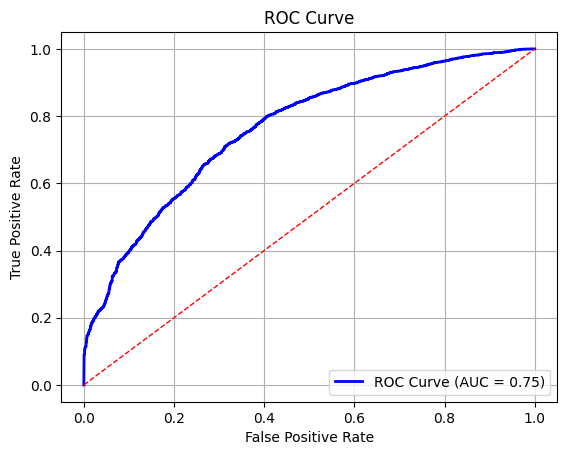

In [1025]:
y_pred = bagg_tuned.predict_proba(X_val_scaled)[:,1]

fpr, tpr, threshold = roc_curve(y_val, y_pred)
print(f"AUC: {roc_auc:.2f}")


plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=1, linestyle='--') 
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

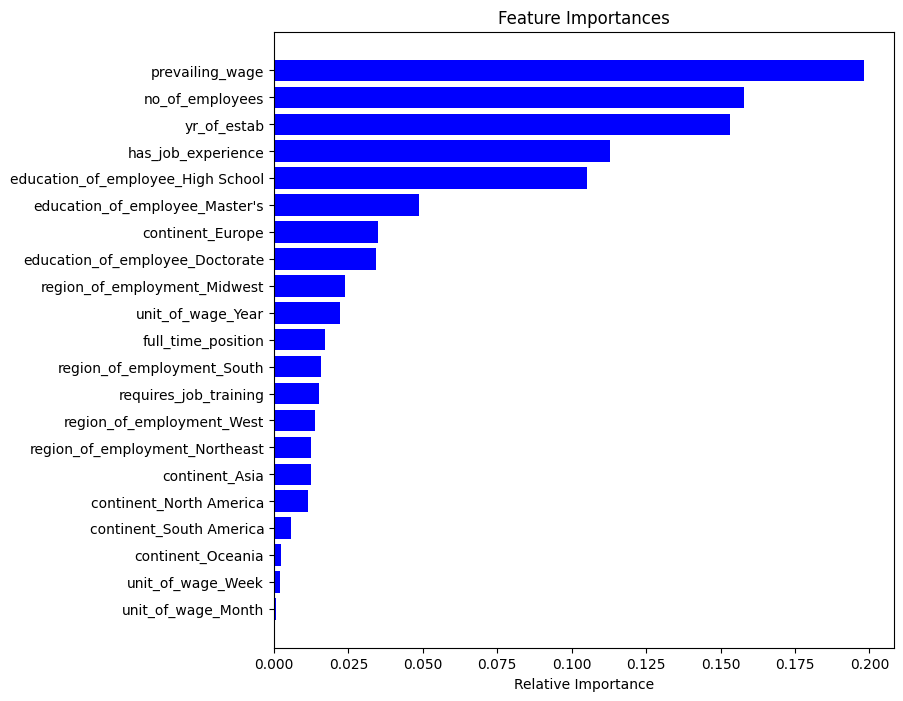

In [1033]:
feature_names = list(X_train.columns)
importances = np.mean([tree.feature_importances_ for tree in bagg_tuned.estimators_], axis=0)
indices = np.argsort(importances)

plt.figure(figsize=(8, 8))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="blue", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

## Random Forest Hyperparameter Tuning Using RandomizedSearchCV

In [700]:
parameters_rf = {
    'n_estimators': [25, 50, 75, 100],
    'max_samples': [0.3, 0.5, 0.7],
    'max_features': [0.4, 'sqrt', 'log2'],
    'max_depth': [5, 8, 10, 12, 15],
    'min_samples_split': [5, 10, 15, 20],
    'criterion': ['gini', 'entropy']
}

In [703]:
%%time

rf_model = RandomForestClassifier(random_state= 42)

grid_obj_rf = RandomizedSearchCV(
    estimator= rf_model,
    param_distributions= parameters_rf,
    cv= 5,
    n_iter= 30,
    scoring= 'f1',
    n_jobs= -1,
)

grid_obj_rf.fit(X_train_over, y_train_over)

CPU times: total: 4.03 s
Wall time: 36.8 s


RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': [5, 8, 10, 12, 15],
                                        'max_features': [0.4, 'sqrt', 'log2'],
                                        'max_samples': [0.3, 0.5, 0.7],
                                        'min_samples_split': [5, 10, 15, 20],
                                        'n_estimators': [25, 50, 75, 100]},
                   scoring='f1')

In [705]:
rf_tuned = grid_obj_rf.best_estimator_
print(rf_tuned)

RandomForestClassifier(max_depth=15, max_features='log2', max_samples=0.5,
                       min_samples_split=20, random_state=42)


**Train**

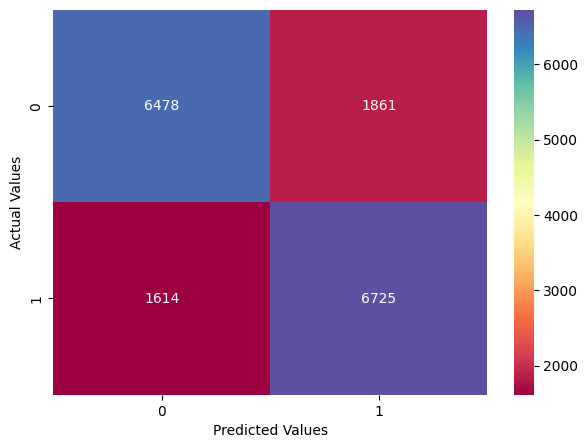

In [708]:
confusion_matrix_stats(rf_tuned, X_train_over, y_train_over)

**Validation**

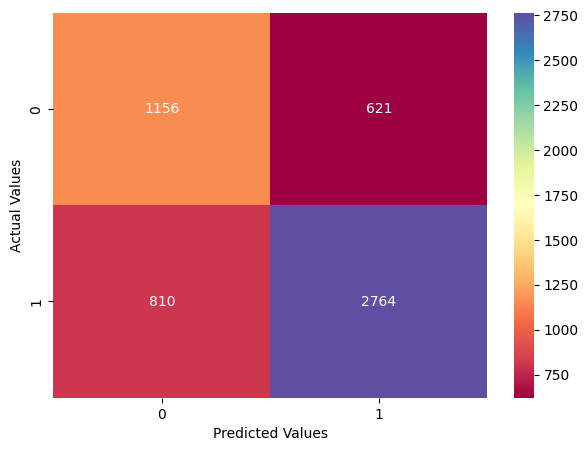

In [711]:
confusion_matrix_stats(rf_tuned, X_val_scaled, y_val)

**Train**

In [714]:
rf_tuned_perf_train = model_performance_stats(rf_tuned, X_train_over, y_train_over)
rf_tuned_perf_train

,Accuracy,Recall,Precision,F1
0,0.791642,0.806452,0.783252,0.794682


**Validation**

In [717]:
rf_tuned_perf_val = model_performance_stats(rf_tuned, X_val_scaled, y_val)
rf_tuned_perf_val

,Accuracy,Recall,Precision,F1
0,0.732573,0.773363,0.816544,0.794367


**Train**

AUC: 0.75


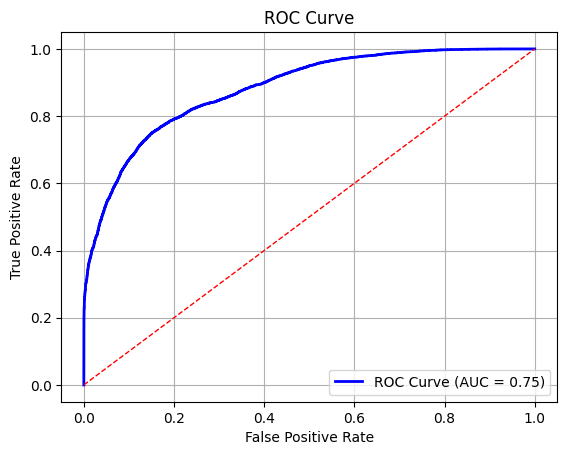

In [720]:
y_pred = rf_tuned.predict_proba(X_train_over)[:,1]

fpr, tpr, threshold = roc_curve(y_train_over, y_pred)
print(f"AUC: {roc_auc:.2f}")


plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=1, linestyle='--') 
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

**Validation**

AUC: 0.75


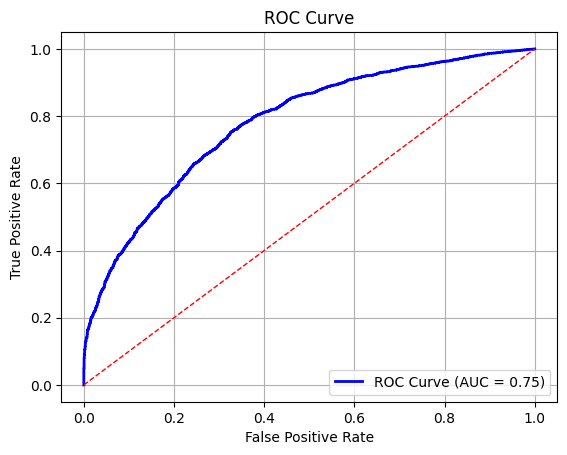

In [730]:
y_pred = rf_tuned.predict_proba(X_val_scaled)[:,1]

fpr, tpr, threshold = roc_curve(y_val, y_pred)
print(f"AUC: {roc_auc:.2f}")


plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=1, linestyle='--') 
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

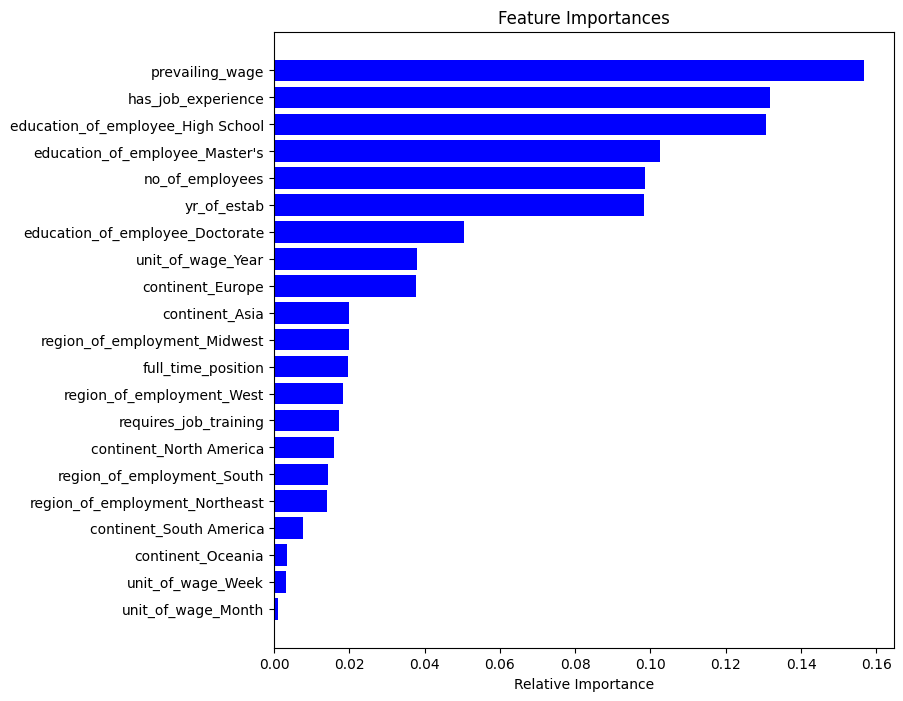

In [983]:
feature_names = list(X_train.columns)

importances = rf_tuned.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8, 8))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="blue", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

## Ada Boosting Hyperparameter Tuning Using RandomizedSearchCV

In [732]:
parameters_Ad = {
    'n_estimators': [25, 50, 75, 100],
    'learning_rate': [0.01, 0.1, 0.5, 1.0],
    'base_estimator__max_depth': [5,7,9,12,15],
    'base_estimator__min_samples_split': [2, 5, 10],
    'base_estimator__criterion': ['gini', 'entropy']
}

In [735]:
%%time

ad_model = AdaBoostClassifier(base_estimator= DecisionTreeClassifier(random_state= 42),random_state= 42)

grid_obj_Ad = RandomizedSearchCV(
    estimator= ad_model,
    param_distributions= parameters_Ad,
    n_iter= 30,
    cv= 5,
    scoring= 'f1',
    n_jobs= -1,
)

grid_obj_Ad.fit(X_train_over, y_train_over)

CPU times: total: 9.8 s
Wall time: 5min 46s


RandomizedSearchCV(cv=5,
                   estimator=AdaBoostClassifier(base_estimator=DecisionTreeClassifier(random_state=42),
                                                random_state=42),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'base_estimator__criterion': ['gini',
                                                                      'entropy'],
                                        'base_estimator__max_depth': [5, 7, 9,
                                                                      12, 15],
                                        'base_estimator__min_samples_split': [2,
                                                                              5,
                                                                              10],
                                        'learning_rate': [0.01, 0.1, 0.5, 1.0],
                                        'n_estimators': [25, 50, 75, 100]},
                   scoring='f1')

In [743]:
Ad_tuned = grid_obj_Ad.best_estimator_
print(Ad_tuned)

AdaBoostClassifier(base_estimator=DecisionTreeClassifier(max_depth=7,
                                                         min_samples_split=10,
                                                         random_state=42),
                   learning_rate=0.1, n_estimators=75, random_state=42)


**Train**

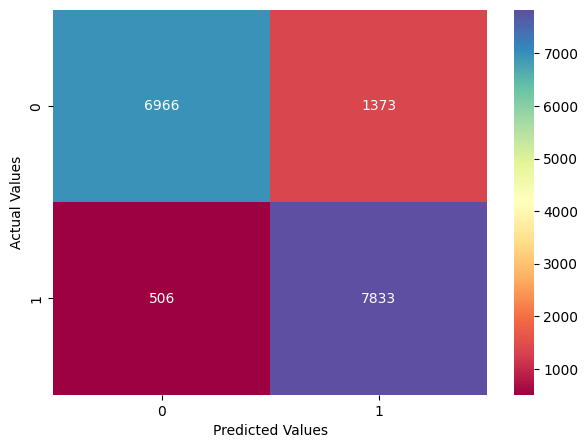

In [745]:
confusion_matrix_stats(Ad_tuned, X_train_over, y_train_over)

**Validation**

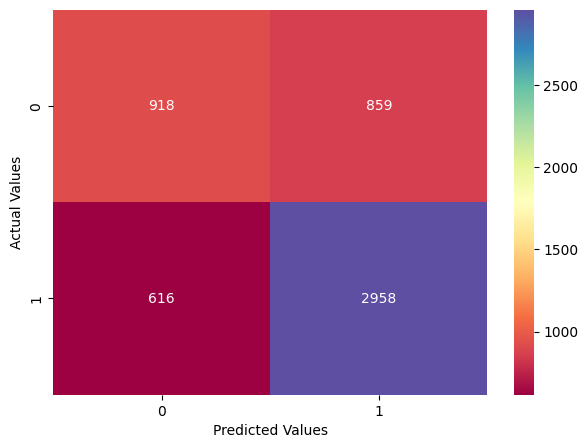

In [747]:
confusion_matrix_stats(Ad_tuned, X_val_scaled, y_val)

**Train**

In [749]:
Ad_tuned_perf_train = model_performance_stats(Ad_tuned, X_train_over, y_train_over)
Ad_tuned_perf_train

,Accuracy,Recall,Precision,F1
0,0.887337,0.939321,0.850858,0.892904


**Validation**

In [751]:
Ad_tuned_perf_val = model_performance_stats(Ad_tuned, X_val_scaled, y_val)
Ad_tuned_perf_val

,Accuracy,Recall,Precision,F1
0,0.724351,0.827644,0.774954,0.800433


**Train**

AUC: 0.75


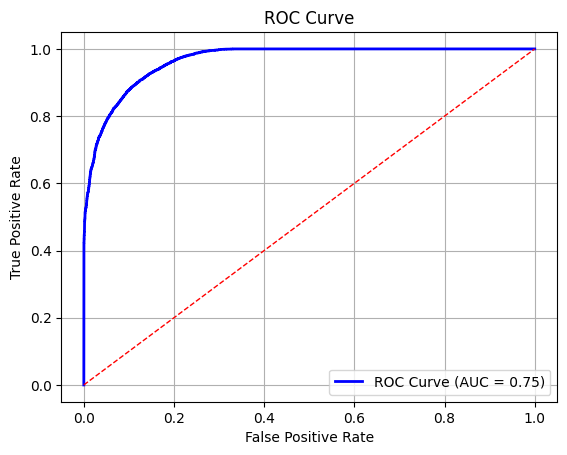

In [763]:
y_pred = Ad_tuned.predict_proba(X_train_over)[:,1]

fpr, tpr, threshold = roc_curve(y_train_over, y_pred)
print(f"AUC: {roc_auc:.2f}")


plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=1, linestyle='--') 
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

**Validation**

AUC: 0.75


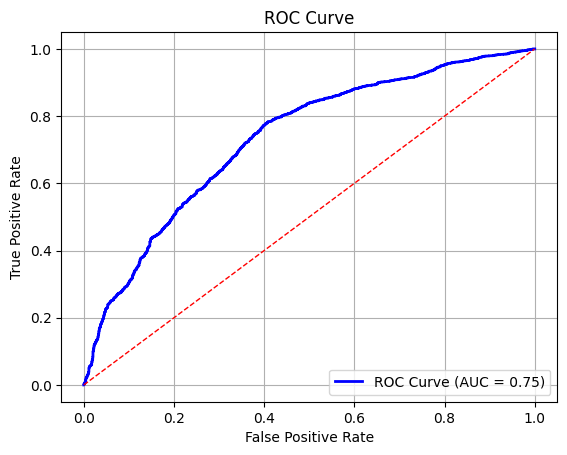

In [757]:
y_pred = Ad_tuned.predict_proba(X_val_scaled)[:,1]

fpr, tpr, threshold = roc_curve(y_val, y_pred)
print(f"AUC: {roc_auc:.2f}")


plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=1, linestyle='--') 
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

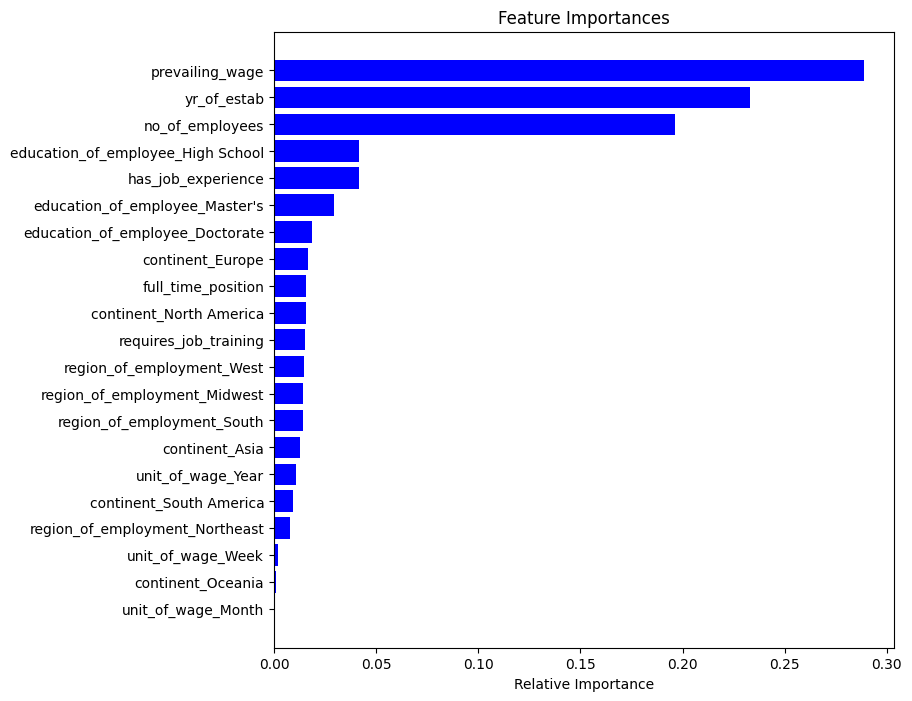

In [985]:
feature_names = list(X_train.columns)

importances = Ad_tuned.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8, 8))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="blue", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

## XGBoosting Hyperparameter Tuning Using RandomizedSearchCV

In [765]:
parameters_XG = {
    'n_estimators': [50, 100, 150, 200], 
    'learning_rate': [0.01, 0.1, 0.2, 0.3],  
    'max_depth': [3, 5, 7, 10],
    'gamma': [0, 0.1, 0.3, 0.5], 
    'subsample': [0.5, 0.7, 1.0], 
    'colsample_bytree': [0.5, 0.7, 1.0],
    'colsample_bylevel':[0.7, 0.8, 0.9, 1]
}

In [771]:
%%time

XG_model = XGBClassifier(random_state= 42)

grid_obj_XG = RandomizedSearchCV(
    estimator= XG_model,
    param_distributions= parameters_XG,
    n_iter= 30,
    cv= 5,
    scoring= 'f1',
    n_jobs= -1,
)

grid_obj_XG.fit(X_train_over, y_train_over)

CPU times: total: 4.5 s
Wall time: 45.2 s


RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constrain...
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'colsample_bylevel': [0.7, 0.8, 0.9, 1],
                                        'colsample_bytree': [0.5, 0.7, 1.0],
                                        'gamma': [0, 0.1, 0.3, 0.5],
                                        'learning_rate': [0.01, 0.1, 0.2, 0.3],
                                        'max_depth': [3, 5, 7, 10],
                                        'n_estimators': [50, 100, 150, 200],
                                        'subsample': [0.5, 0.7, 1.0]},
                   scoring='f1')

In [773]:
XG_tuned = grid_obj_XG.best_estimator_
print(XG_tuned)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=0.9, colsample_bynode=None,
              colsample_bytree=0.5, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=0, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=10,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)


**Train**

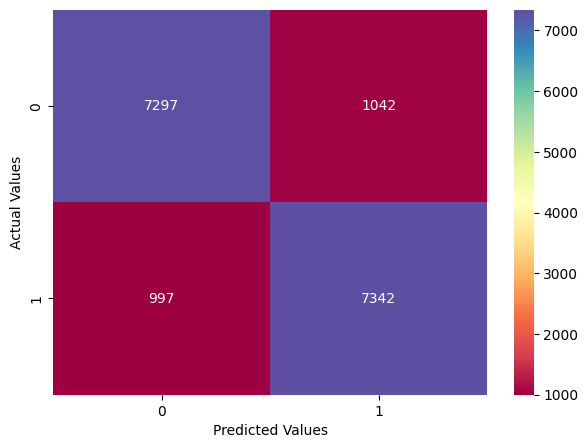

In [775]:
confusion_matrix_stats(XG_tuned, X_train_over, y_train_over)

**Validation**

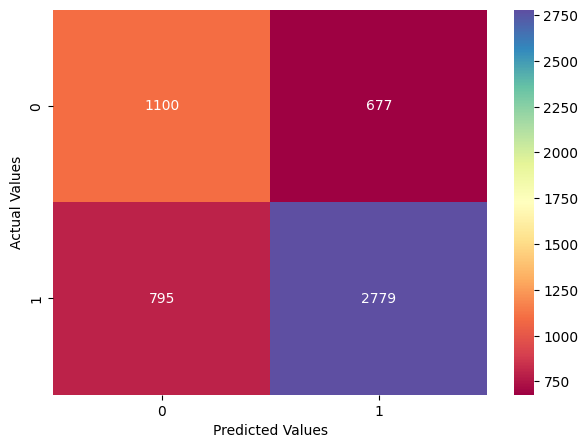

In [777]:
confusion_matrix_stats(XG_tuned, X_val_scaled, y_val)

**Train**

In [779]:
XG_tuned_perf_train = model_performance_stats(XG_tuned, X_train_over, y_train_over)
XG_tuned_perf_train

,Accuracy,Recall,Precision,F1
0,0.877743,0.880441,0.875716,0.878072


**Validation**

In [781]:
XG_tuned_perf_val = model_performance_stats(XG_tuned, X_val_scaled, y_val)
XG_tuned_perf_val

,Accuracy,Recall,Precision,F1
0,0.724911,0.77756,0.804109,0.790612


**Train**

AUC: 0.75


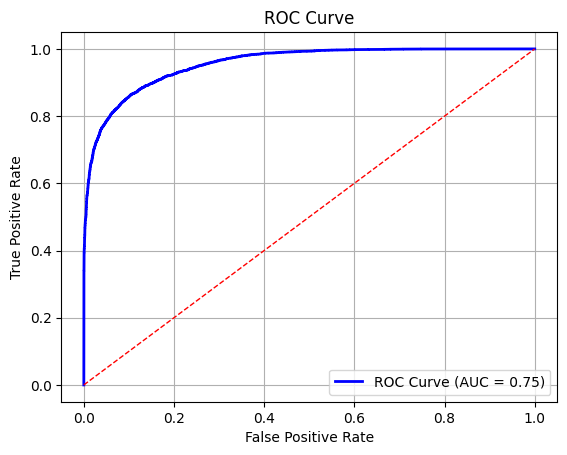

In [789]:
y_pred = XG_tuned.predict_proba(X_train_over)[:,1]

fpr, tpr, threshold = roc_curve(y_train_over, y_pred)
print(f"AUC: {roc_auc:.2f}")


plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=1, linestyle='--') 
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

**Validation**

AUC: 0.75


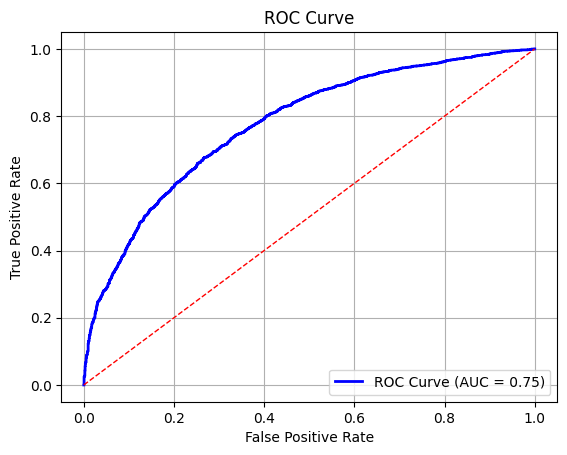

In [785]:
y_pred = XG_tuned.predict_proba(X_val_scaled)[:,1]

fpr, tpr, threshold = roc_curve(y_val, y_pred)
print(f"AUC: {roc_auc:.2f}")


plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=1, linestyle='--') 
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

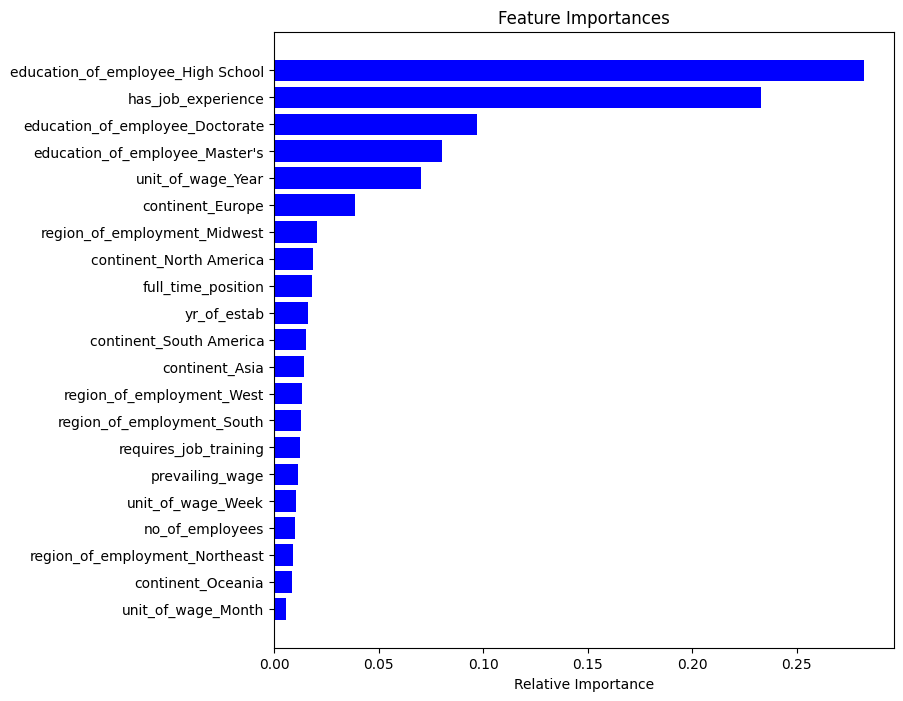

In [987]:
feature_names = list(X_train.columns)

importances = XG_tuned.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8, 8))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="blue", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

# <a name=link6>Model Performance Comparison and Final Model Selection</a>

### Training performance comparison

In [1052]:
models_train_comp_df = pd.concat(
    [
        decision_tree_tuned_perf_train.T,
        Bagging_tuned_perf_train.T,
        rf_tuned_perf_train.T,
        Ad_tuned_perf_train.T,
        XG_tuned_perf_train.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Decision Tree Tuned",
    "Bagging Tuned",
    "Random Forest Tuned",
    "Ada-Boost Tuned",
    "XGBoost Tuned"
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Decision Tree Tuned,Bagging Tuned,Random Forest Tuned,Ada-Boost Tuned,XGBoost Tuned
Accuracy,0.719151,0.883439,0.791642,0.887337,0.877743
Recall,0.757045,0.866651,0.806452,0.939321,0.880441
Precision,0.703712,0.896761,0.783252,0.850858,0.875716
F1,0.729405,0.881449,0.794682,0.892904,0.878072


1. **Decision Tree Tuned**
    - Lowest performance among all tuned models.
    - Indicates limited learning capacity compared to ensemble methods
      .
2. **Bagging Tuned**
    - Highest precision (0.897), meaning fewer false positives.
    - Very strong F1 and accuracy, just slightly behind AdaBoost.

3. **Random Forest Tuned**
    - Moderate performance, better than Decision Tree but behind ensemble methods.
    - Good balance but not leading in any metric.

4. **AdaBoost Tuned**
    - Best overall performer in accuracy, recall, and F1 score.
    - Indicates strong learning and ability to capture positive cases (high recall).
    - Slightly lower precision than Bagging, but still very good.

5. **XGBoost Tuned**
    - Very balanced performance across all metrics.
    - Slightly lower than AdaBoost in recall and F1, but more consistent.

### Validation performance comparison

In [1056]:
models_train_comp_df = pd.concat(
    [
        decision_tree_tuned_perf_val.T,
        Bagging_tuned_perf_val.T,
        rf_tuned_perf_val.T,
        Ad_tuned_perf_val.T,
        XG_tuned_perf_val.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Decision Tree Tuned",
    "Bagging Tuned",
    "Random Forest Tuned",
    "Ada-Boost Tuned",
    "XGBoost Tuned"
]
print("Validation performance comparison:")
models_train_comp_df

Validation performance comparison:


,Decision Tree Tuned,Bagging Tuned,Random Forest Tuned,Ada-Boost Tuned,XGBoost Tuned
Accuracy,0.722669,0.712951,0.732573,0.724351,0.724911
Recall,0.757135,0.747902,0.773363,0.827644,0.777560
Precision,0.814570,0.808041,0.816544,0.774954,0.804109
F1,0.784803,0.776809,0.794367,0.800433,0.790612


1. **Decision Tree Tuned**
    - Performs better than Bagging in accuracy and F1.
    - Still outperformed by ensemble methods.
      
2. **Bagging Tuned**
    - Moderate performance across all metrics.
    - Slightly lower than Random Forest and XGBoost

3. **Random Forest Tuned**
    - Best accuracy (0.733) and precision (0.817).
    - Balanced model with strong generalization.
    - Slightly lower recall than AdaBoost, but still strong.

4. **AdaBoost Tuned**
    - Best recall (0.828) and F1 score (0.800).
    - Ideal when it's important to identify as many positive cases as possible (e.g., visa approvals).
    - Slightly lower precision, indicating more false positives.

5. **XGBoost Tuned**
    - Very balanced across all metrics.
    - Slightly behind AdaBoost and Random Forest in F1, but still highly competitive.

## **Final Model**: AdaBoost Tuned can be used for Test data

1. Consistently high performance across all datasets.
2. Excellent balance between precision and recall.
3. Generalizes well, minimal drop from training to validation to test.
4. It has the highest F1 score compared to other models.

In [1061]:
ad_tuned_perf_test = model_performance_stats(Ad_tuned, X_test_scaled, y_test)
ad_tuned_perf_test

,Accuracy,Recall,Precision,F1
0,0.710099,0.823898,0.761543,0.791494


### Feature Importance of Ada-Boosting Tuned Model

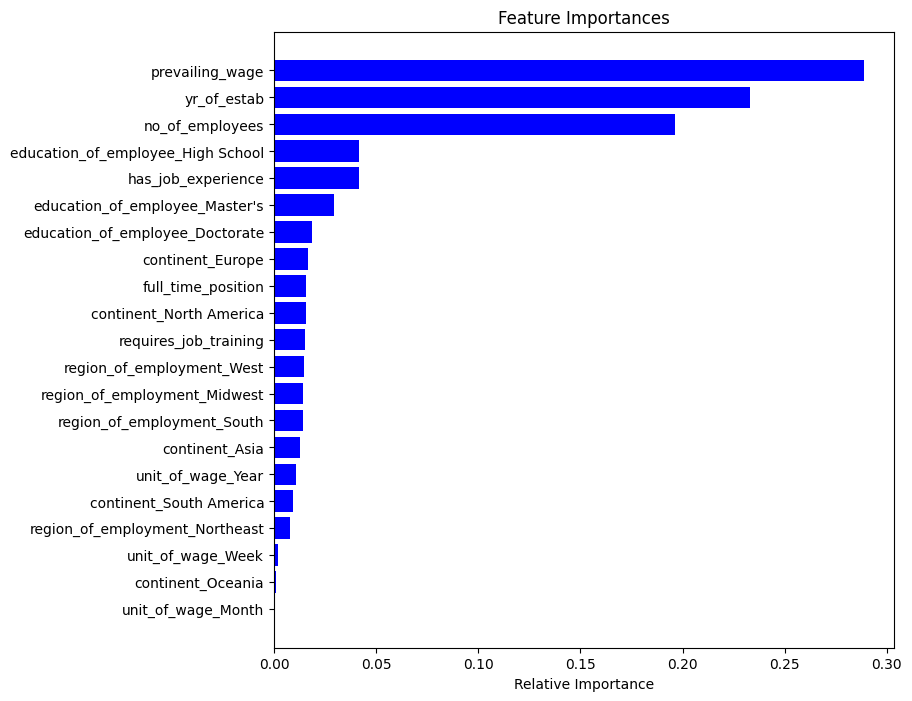

In [1035]:
feature_names = list(X_train.columns)

importances = Ad_tuned.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8, 8))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="blue", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

### Top Features
1. **prevailing_wage**
    - Most important feature.
      
    - Suggests that higher wages significantly increase the likelihood of visa certification.

2. **yr_of_estab** - Older companies are more likely to have certified cases, possibly due to credibility and stability.

3. **no_of_employees** - Larger organizations tend to have more certified applications, likely due to better compliance and resources.

## Conclusion

This performance confirms that your AdaBoost Tuned model is:

- Well-generalized (minimal overfitting),
- Balanced in handling both false positives and false negatives,
- A strong candidate for deployment or further optimization.

# <a name=link7>Actionable Insights & Recommendations</a>

## Actionable Insights

1. **Model Performance**
   - AdaBoost Tuned emerged as the best-performing model with:
        - Accuracy: 71.0%
        - Recall: 82.4%
        - Precision: 76.2%
        - F1 Score: 79.1%
     
    It consistently outperformed other models across training, validation, and test sets, especially in identifying true positive cases (Certified applications).

2. **Feature Impact**

    - Higher prevailing wages, older year of establishment, and larger number of employees are positively correlated with certification.
    - Full-time positions and job experience significantly increase the likelihood of certification.
   
    - Applicants from Asia dominate the dataset, but North America shows a higher certification rate proportionally.


3. **Sampling Techniques**

    - Oversampling (SMOTE) improved model balance and recall without overfitting.
    - Undersampling led to lower generalization and should be avoided unless data imbalance is extreme.

## Business Recommendations

1. **Adopt AdaBoost Tuned for Decision Support** - Use the AdaBoost model in your visa application review pipeline to prioritize high-certainty approvals and flag borderline cases for manual review.


2. **Optimize Job Offer Criteria** - Encourage employers to offer competitive wages, full-time roles, and training opportunities to improve certification chances.
  
    
3. **Targeted Employer Engagement** - Focus outreach and support on smaller or newer companies to help them align with certification trends (e.g., wage benchmarks, job role structuring).

     
4. **Applicant Guidance** - Provide clear guidance to applicants on the importance of job experience and education level in influencing outcomes.

5. **Monitor and Update Models** - Regularly retrain and validate the model with new data to adapt to policy or market changes.